In [1]:
import os

print(os.listdir('/kaggle/input/datasets/melekkchaou'))

['echonext-waveforms']


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input/datasets/melekkchaou'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_val_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_val_tabular_features.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_no_split_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/echonext_metadata_100k.csv
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_no_split_tabular_features.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_train_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_test_tabular_features.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_test_waveforms.npy
/kaggle/input/datasets/melekkchaou/echonext-waveforms/EchoNext_train_tabular_features.npy


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
meta = pd.read_csv("/kaggle/input/datasets/melekkchaou/echonext-waveforms/echonext_metadata_100k.csv")

print("Shape of metadata :", meta.shape)

Shape of metadata : (100000, 39)


# Appercu général

In [5]:
meta.head()

,ecg_number,ecg_key,patient_key,age_at_ecg,sex,acquisition_year,location_setting,race_ethnicity,most_recent_ecg,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,lvef_lte_45_flag,lvwt_gte_13_flag,aortic_stenosis_moderate_or_greater_flag,aortic_regurgitation_moderate_or_greater_flag,mitral_regurgitation_moderate_or_greater_flag,tricuspid_regurgitation_moderate_or_greater_flag,pulmonary_regurgitation_moderate_or_greater_flag,rv_systolic_dysfunction_moderate_or_greater_flag,pericardial_effusion_moderate_large_flag,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag,aortic_stenosis_value,aortic_regurgitation_value,mitral_regurgitation_value,tricuspid_regurgitation_value,pulmonary_regurgitation_value,rv_systolic_function_value,pericardial_effusion_value,ivs_measurement,lvpw_measurement,pasp_value,tr_max_velocity_value,lvef_value,split
0,0,8520052,902618160,88,male,2014,emergency,other,1,117,117.0,162.0,116,463.0,0,0,0,0,0,0,0,0,0,0,0,0,none,none,mild,none,presumed none,normal,trace,1.0,1.0,NaN,NaN,62.5,train
1,1,7283576,4764241080,69,female,2019,inpatient,black,0,99,99.0,128.0,74,449.0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
2,2,8769869,4214459612,22,male,2017,inpatient,white,0,86,86.0,144.0,84,485.0,0,0,0,0,0,0,0,0,0,1,0,1,none,none,none,none,none,mildly_reduced,small,1.1,1.1,51.0,NaN,57.5,train
3,3,6379904,6205191619,70,male,2022,emergency,hispanic,0,68,68.0,136.0,80,427.0,1,0,0,0,0,0,0,0,0,0,0,1,none,none,none,none,none,normal,none,0.9,1.0,NaN,NaN,45.0,train
4,4,9619545,8380688329,54,male,2013,inpatient,other,0,90,93.0,NaN,188,582.0,1,0,0,0,0,0,0,1,0,0,0,1,presumed none,mild,mild,mild,none,moderately_reduced,small,1.2,1.0,38.0,2.6,20.0,train


In [6]:
meta.sample(5)

,ecg_number,ecg_key,patient_key,age_at_ecg,sex,acquisition_year,location_setting,race_ethnicity,most_recent_ecg,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,lvef_lte_45_flag,lvwt_gte_13_flag,aortic_stenosis_moderate_or_greater_flag,aortic_regurgitation_moderate_or_greater_flag,mitral_regurgitation_moderate_or_greater_flag,tricuspid_regurgitation_moderate_or_greater_flag,pulmonary_regurgitation_moderate_or_greater_flag,rv_systolic_dysfunction_moderate_or_greater_flag,pericardial_effusion_moderate_large_flag,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag,aortic_stenosis_value,aortic_regurgitation_value,mitral_regurgitation_value,tricuspid_regurgitation_value,pulmonary_regurgitation_value,rv_systolic_function_value,pericardial_effusion_value,ivs_measurement,lvpw_measurement,pasp_value,tr_max_velocity_value,lvef_value,split
4572,4572,9102992,3295410615,66,female,2018,inpatient,unknown,0,131,131.0,136.0,78,460.0,1,1,0,0,0,1,0,1,0,0,0,1,mild,none,mild,moderate,none,moderately_reduced,trace,1.4,1.3,39.0,2.9,22.5,train
66459,66459,9644222,7519806506,81,male,2016,procedural,white,0,46,46.0,240.0,90,402.0,0,1,1,0,0,0,0,0,0,0,0,1,severe,none,mild,none,none,normal,none,1.2,1.4,32.1,2.5,69.3,train
33115,33115,6612644,2938168509,41,male,2022,emergency,black,1,81,81.0,196.0,102,478.0,1,0,0,0,0,1,0,1,0,1,0,1,none,none,mild,severe,mild,severely_reduced,none,1.1,1.0,46.0,2.5,10.0,train
36667,36667,9137088,6493171237,52,female,2015,outpatient,other,1,49,49.0,140.0,90,424.0,0,0,0,0,0,0,0,0,0,0,0,0,none,none,none,none,none,normal,none,0.8,0.8,30.0,NaN,60.0,train
81958,81958,10409050,4335457530,78,female,2018,inpatient,white,1,136,NaN,NaN,72,412.0,0,0,0,0,0,0,0,0,0,0,0,0,none,none,none,presumed none,presumed none,normal,small,1.0,1.0,38.0,2.9,62.5,test


In [7]:
meta.tail()

,ecg_number,ecg_key,patient_key,age_at_ecg,sex,acquisition_year,location_setting,race_ethnicity,most_recent_ecg,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,lvef_lte_45_flag,lvwt_gte_13_flag,aortic_stenosis_moderate_or_greater_flag,aortic_regurgitation_moderate_or_greater_flag,mitral_regurgitation_moderate_or_greater_flag,tricuspid_regurgitation_moderate_or_greater_flag,pulmonary_regurgitation_moderate_or_greater_flag,rv_systolic_dysfunction_moderate_or_greater_flag,pericardial_effusion_moderate_large_flag,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag,aortic_stenosis_value,aortic_regurgitation_value,mitral_regurgitation_value,tricuspid_regurgitation_value,pulmonary_regurgitation_value,rv_systolic_function_value,pericardial_effusion_value,ivs_measurement,lvpw_measurement,pasp_value,tr_max_velocity_value,lvef_value,split
99995,99995,11224461,3435945264,62,male,2022,inpatient,hispanic,0,81,81.0,320.0,98,443.0,0,0,0,0,0,0,0,0,0,0,0,0,none,none,mild,mild,none,normal,trace,1.2,1.1,43.0,2.7,62.5,no_split
99996,99996,11226230,6249738043,36,female,2022,inpatient,black,0,98,98.0,116.0,78,428.0,0,0,0,0,0,0,0,0,0,0,0,0,none,none,none,mild,none,normal,small,1.1,1.2,NaN,1.8,57.5,no_split
99997,99997,11226538,2859644849,69,male,2022,inpatient,hispanic,0,84,84.0,136.0,86,437.0,0,1,0,0,0,0,0,0,1,0,0,1,none,none,none,none,none,normal,moderate,0.9,1.3,NaN,NaN,60.0,no_split
99998,99998,11226778,5302291537,46,female,2022,inpatient,unknown,0,111,111.0,128.0,70,437.0,0,0,0,0,0,0,0,0,1,0,0,1,none,none,none,none,presumed none,normal,moderate,1.0,1.0,NaN,NaN,57.5,no_split
99999,99999,11233216,5377105766,76,male,2022,inpatient,other,0,79,NaN,NaN,180,630.0,1,0,0,0,0,0,0,0,0,0,0,1,presumed none,none,none,none,presumed none,mildly_reduced,NaN,1.0,0.8,NaN,NaN,22.5,no_split


# Informations générales

In [8]:
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   ecg_number                                        100000 non-null  int64  
 1   ecg_key                                           100000 non-null  int64  
 2   patient_key                                       100000 non-null  int64  
 3   age_at_ecg                                        100000 non-null  int64  
 4   sex                                               100000 non-null  object 
 5   acquisition_year                                  100000 non-null  int64  
 6   location_setting                                  100000 non-null  object 
 7   race_ethnicity                                    100000 non-null  object 
 8   most_recent_ecg                                   100000 non-null  int64  
 9   ventr

# Types de variables

In [9]:
meta.dtypes.value_counts()

int64      20
object     11
float64     8
Name: count, dtype: int64

In [10]:
categorical_cols = meta.select_dtypes(include=['object']).columns

numerical_cols = meta.select_dtypes(
    include=['int64','float64']
).columns

print("Variables numériques :", len(numerical_cols))
print("Variables catégorielles :", len(categorical_cols))

Variables numériques : 28
Variables catégorielles : 11


# Valeurs manquantes

In [11]:
# Nombre total
meta.isnull().sum()

ecg_number                                              0
ecg_key                                                 0
patient_key                                             0
age_at_ecg                                              0
sex                                                     0
acquisition_year                                        0
location_setting                                        0
race_ethnicity                                          0
most_recent_ecg                                         0
ventricular_rate                                        0
atrial_rate                                           613
pr_interval                                         10369
qrs_duration                                            0
qt_corrected                                            1
lvef_lte_45_flag                                        0
lvwt_gte_13_flag                                        0
aortic_stenosis_moderate_or_greater_flag                0
aortic_regurgi

In [12]:
#Par colonne
missing = pd.DataFrame({
    'Missing Count': meta.isnull().sum(),
    'Missing %': round(meta.isnull().mean()*100,2)
})

missing = missing.sort_values(
    by='Missing %',
    ascending=False
)

missing

,Missing Count,Missing %
tr_max_velocity_value,54996,55.00
pasp_value,43424,43.42
pericardial_effusion_value,11823,11.82
pr_interval,10369,10.37
ivs_measurement,9133,9.13
lvpw_measurement,9125,9.12
rv_systolic_function_value,9096,9.10
tricuspid_regurgitation_value,9036,9.04
aortic_stenosis_value,9003,9.00
aortic_regurgitation_value,9003,9.00


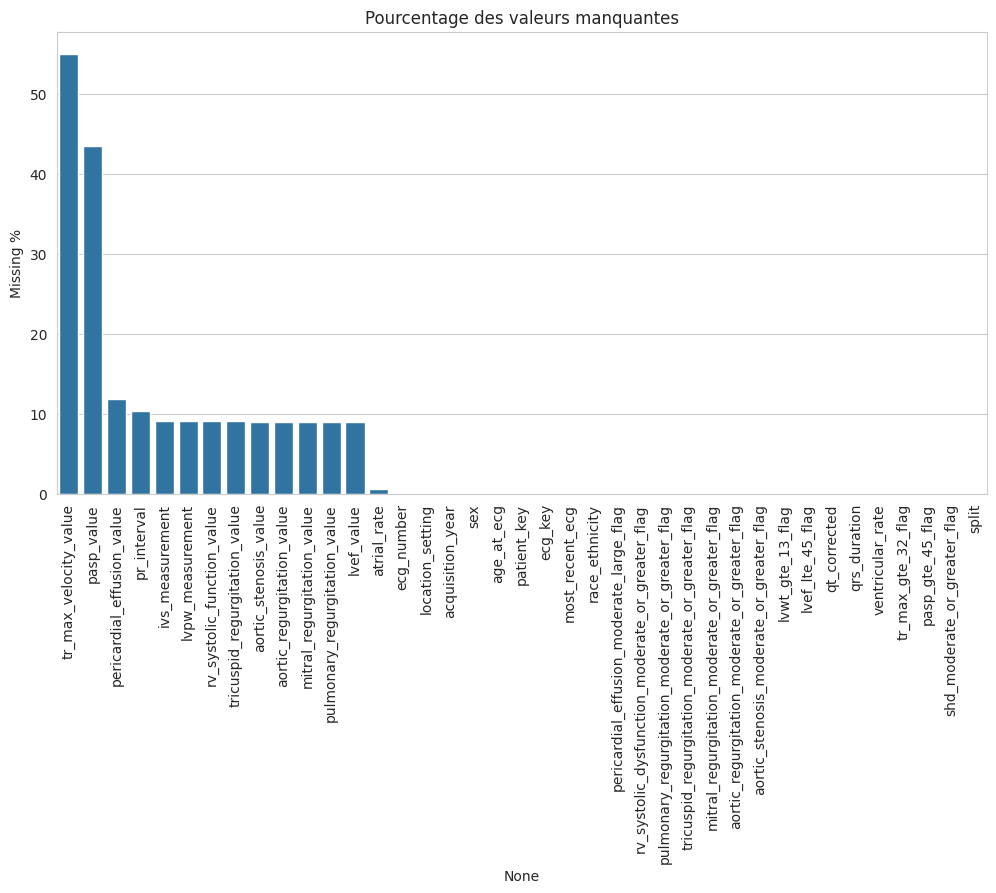

In [13]:
# Visualisation
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.index,
    y=missing['Missing %']
)

plt.xticks(rotation=90)
plt.title("Pourcentage des valeurs manquantes")
plt.show()

*Variables qui ont un Impact Clinique Majeur*

Même si elles ont des valeurs manquantes, ces variables sont le cœur même du diagnostic de l'insuffisance cardiaque. Interdiction de les supprimer.

* lvef_value (9.14 % de valeurs manquantes) : La fraction d'éjection (FEVG) est l'indicateur n°1 pour classer l'insuffisance cardiaque (à fraction réduite, moyennement altérée ou préservée). 9 % est un excellent taux, très facile à imputer.

* pasp_value (43.42 % de valeurs manquantes) : La pression artérielle systolique pulmonaire. C'est une mine d'or pour détecter l'insuffisance cardiaque droite ou avancée (liée à l'hypertension pulmonaire). Malgré les 43 %, elle apporte trop de valeur clinique pour être jetée.

* ivs_measurement & lvpw_measurement (~9.13 %) : L'épaisseur du septum et de la paroi. Crucial pour repérer l'hypertrophie ventriculaire gauche (souvent précurseur de l'insuffisance cardiaque à fraction d'éjection préservée - IC-FEP).

* pr_interval (10.37 %) : Indicateur ECG précieux pour les blocs auriculoventriculaires ou les troubles de conduction liés aux cardiopathies structurelles.

* Les valeurs cliniques graduées (~9 %) (mitral_regurgitation_value, tricuspid_regurgitation_value, rv_systolic_function_value, pericardial_effusion_value) : Elles qualifient la sévérité des atteintes valvulaires et de la fonction droite, indispensables pour la détection précoce.

# Importance des variables

Shape X : (100000, 60)
Shape y : (100000,)

Top 20 variables :
                                             Feature  Importance
23                                        lvef_value    0.500278
18                      shd_moderate_or_greater_flag    0.148223
14  rv_systolic_dysfunction_moderate_or_greater_flag    0.059911
16                                  pasp_gte_45_flag    0.058556
54                 rv_systolic_function_value_normal    0.058140
11     mitral_regurgitation_moderate_or_greater_flag    0.034179
8                                   lvwt_gte_13_flag    0.022936
42                   mitral_regurgitation_value_none    0.021881
19                                   ivs_measurement    0.020454
45            tricuspid_regurgitation_value_moderate    0.016100
9           aortic_stenosis_moderate_or_greater_flag    0.010618
15          pericardial_effusion_moderate_large_flag    0.004888
41               mitral_regurgitation_value_moderate    0.004366
7                          

<Figure size 1000x800 with 0 Axes>

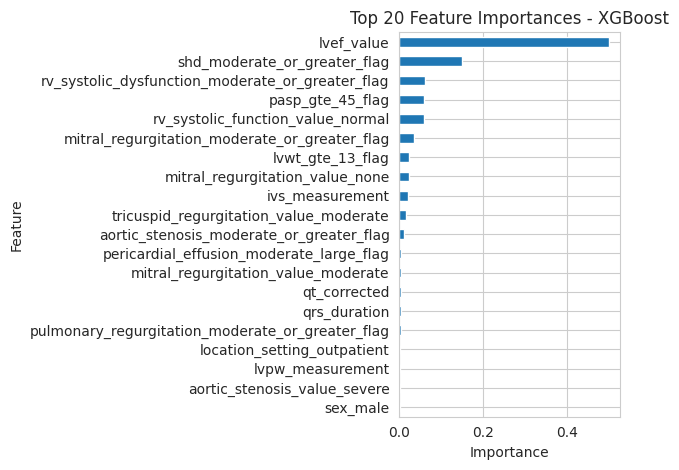

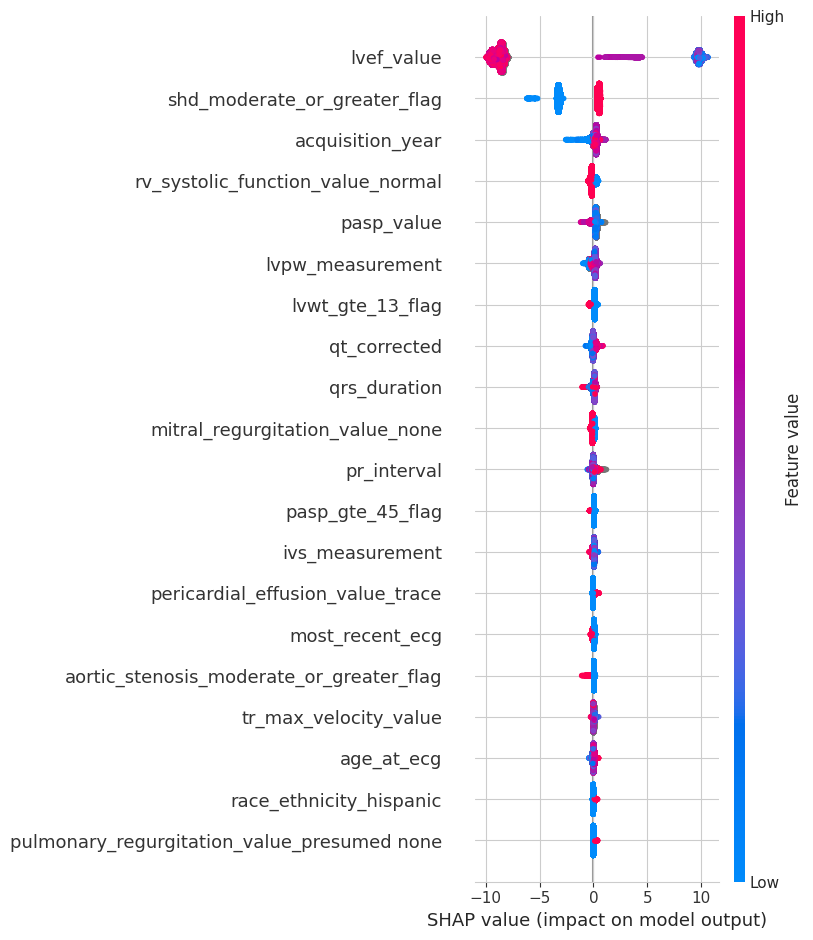

In [14]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# 2. Définir la cible
target = "lvef_lte_45_flag"

# 3. Colonnes à exclure
cols_to_drop = [
    "ecg_number",
    "ecg_key",
    "patient_key",
    "split",
    target
]

# 4. Variables explicatives et cible
X = meta.drop(columns=cols_to_drop)
y = meta[target]

# 5. Encodage des variables catégorielles
X = pd.get_dummies(X, drop_first=True)

print("Shape X :", X.shape)
print("Shape y :", y.shape)


# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 7. Modèle XGBoost
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# 8. Importance des variables

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# 9. Afficher les 20 plus importantes
print("\nTop 20 variables :")
print(importance_df.head(39))


# 10. Graphique
top_n = 20

plt.figure(figsize=(10,8))

importance_df.head(top_n).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# SHAP
import shap

# Création de l'explainer
explainer = shap.TreeExplainer(model)

# Calcul des valeurs SHAP
shap_values = explainer.shap_values(X_train)

# 1. Summary Plot (le plus important)
shap.summary_plot(
    shap_values,
    X_train
)

In [15]:
import numpy as np

shap_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="MeanAbsSHAP",
    ascending=False
)

print(shap_importance.head(20))

                                        Feature  MeanAbsSHAP
23                                   lvef_value     8.990512
18                 shd_moderate_or_greater_flag     1.800351
1                              acquisition_year     0.212428
54            rv_systolic_function_value_normal     0.212284
21                                   pasp_value     0.210663
20                             lvpw_measurement     0.186420
8                              lvwt_gte_13_flag     0.147776
7                                  qt_corrected     0.120807
6                                  qrs_duration     0.115293
42              mitral_regurgitation_value_none     0.110091
5                                   pr_interval     0.099847
16                             pasp_gte_45_flag     0.083668
19                              ivs_measurement     0.077215
59             pericardial_effusion_value_trace     0.068835
2                               most_recent_ecg     0.068823
9      aortic_stenosis_m

# Doublons 

In [16]:
duplicates = meta.duplicated().sum()

print("Nombre de doublons :", duplicates)

Nombre de doublons : 0


# Description statistique

In [17]:
meta.describe().T

,count,mean,std,min,25%,50%,75%,max
ecg_number,100000.0,4.999950e+04,2.886766e+04,0.0,2.499975e+04,4.999950e+04,7.499925e+04,9.999900e+04
ecg_key,100000.0,8.773790e+06,1.516727e+06,3632711.0,7.688690e+06,8.827948e+06,1.001352e+07,1.128044e+07
patient_key,100000.0,4.990837e+09,2.883732e+09,146550.0,2.476572e+09,4.980672e+09,7.507248e+09,9.999853e+09
age_at_ecg,100000.0,6.117929e+01,1.607706e+01,18.0,5.100000e+01,6.300000e+01,7.300000e+01,9.000000e+01
acquisition_year,100000.0,2.016122e+03,3.857382e+00,2008.0,2.013000e+03,2.016000e+03,2.020000e+03,2.022000e+03
most_recent_ecg,100000.0,3.628600e-01,4.808273e-01,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
ventricular_rate,100000.0,8.357251e+01,2.041984e+01,2.0,6.900000e+01,8.100000e+01,9.500000e+01,2.230000e+02
atrial_rate,99387.0,8.991937e+01,4.392688e+01,0.0,6.900000e+01,8.200000e+01,9.700000e+01,5.760000e+02
pr_interval,89631.0,1.596174e+02,3.252439e+01,30.0,1.380000e+02,1.540000e+02,1.740000e+02,5.440000e+02
qrs_duration,100000.0,9.471732e+01,2.179784e+01,4.0,8.000000e+01,9.000000e+01,1.020000e+02,2.540000e+02


# Analyse des variables numériques

In [18]:
# Moyenne, Médiane, Ecart-Type
stats = pd.DataFrame({
    'Mean': meta[numerical_cols].mean(),
    'Median': meta[numerical_cols].median(),
    'Std': meta[numerical_cols].std(),
    'Min': meta[numerical_cols].min(),
    'Max': meta[numerical_cols].max()
})

stats

,Mean,Median,Std,Min,Max
ecg_number,4.999950e+04,4.999950e+04,2.886766e+04,0.0,9.999900e+04
ecg_key,8.773790e+06,8.827948e+06,1.516727e+06,3632711.0,1.128044e+07
patient_key,4.990837e+09,4.980672e+09,2.883732e+09,146550.0,9.999853e+09
age_at_ecg,6.117929e+01,6.300000e+01,1.607706e+01,18.0,9.000000e+01
acquisition_year,2.016122e+03,2.016000e+03,3.857382e+00,2008.0,2.022000e+03
most_recent_ecg,3.628600e-01,0.000000e+00,4.808273e-01,0.0,1.000000e+00
ventricular_rate,8.357251e+01,8.100000e+01,2.041984e+01,2.0,2.230000e+02
atrial_rate,8.991937e+01,8.200000e+01,4.392688e+01,0.0,5.760000e+02
pr_interval,1.596174e+02,1.540000e+02,3.252439e+01,30.0,5.440000e+02
qrs_duration,9.471732e+01,9.000000e+01,2.179784e+01,4.0,2.540000e+02


In [19]:
# Asymétrie (Skewness)
skewness = pd.DataFrame({
    'Skewness': meta[numerical_cols].skew()
})

skewness.sort_values(
    by='Skewness',
    ascending=False
)

,Skewness
pulmonary_regurgitation_moderate_or_greater_flag,1.090021e+01
aortic_regurgitation_moderate_or_greater_flag,8.725194e+00
pericardial_effusion_moderate_large_flag,5.487422e+00
aortic_stenosis_moderate_or_greater_flag,4.659388e+00
atrial_rate,4.287490e+00
ivs_measurement,3.704736e+00
mitral_regurgitation_moderate_or_greater_flag,2.987557e+00
tr_max_gte_32_flag,2.627992e+00
tricuspid_regurgitation_moderate_or_greater_flag,2.551116e+00
lvpw_measurement,2.197870e+00


Rappel :

Skewness fortement positive (> 1) : Distribution étalée vers la droite. La majorité des valeurs sont basses, et quelques valeurs très élevées créent une "queue" à droite.

Skewness proche de 0 (entre -0.5 et 0.5) : Distribution globalement symétrique (normale).

Skewness négative (< -1) : Distribution étalée vers la gauche. La majorité des valeurs sont élevées, avec quelques valeurs très basses.

*Interprétation*
* **`_flag` (ex: `pulmonary_regurgitation`, `aortic_regurgitation` | Skewness > 2)** : Forte asymétrie positive. Variables binaires (0 ou 1) où la condition médicale est rare. La grande majorité des patients ont 0, quelques rares cas ont 1.
* **`atrial_rate` (4.28) & `ivs_measurement` (3.70)** : Forte asymétrie positive. Majorité de valeurs basses ou standards, avec la présence de quelques patients ayant un rythme auriculaire ou une épaisseur de septum extrêmement élevés.
* **`pr_interval` (1.75), `pasp_value` (1.58), `qrs_duration` (1.50)** : Asymétrie positive marquée. Distribution étalée vers la droite avec des valeurs maximales éloignées de la moyenne (cas cliniques sévères).
* **`ventricular_rate` (0.82), `tr_max_velocity_value` (0.74), `qt_corrected` (0.73)** : Asymétrie positive modérée. Distribution globalement centrée, mais penchant légèrement vers la droite avec quelques valeurs élevées.
* **`patient_key` (0.01), `ecg_number` (~0)** : Distribution parfaitement symétrique. Logique pour des identifiants ou des compteurs indexés.
* **`acquisition_year` (-0.15) & `age_at_ecg` (-0.44)** : Distribution quasi-symétrique. Pour l'âge, la légère valeur négative indique une proportion marginalement plus élevée de patients âgés par rapport aux patients très jeunes.
* **`lvef_value` (-1.16)** : Asymétrie négative. La majorité des patients présentent une fraction d'éjection normale ou haute (valeurs élevées à droite), et une minorité de patients atteints d'insuffisance cardiaque tire la queue de la distribution vers les valeurs basses (à gauche).

In [20]:
# Kurtosis
kurt = pd.DataFrame({
    'Kurtosis': meta[numerical_cols].kurt()
})

kurt.sort_values(
    by='Kurtosis',
    ascending=False
)

,Kurtosis
pulmonary_regurgitation_moderate_or_greater_flag,116.816858
aortic_regurgitation_moderate_or_greater_flag,74.130492
ivs_measurement,61.452534
lvpw_measurement,36.364118
pericardial_effusion_moderate_large_flag,28.112360
atrial_rate,23.752405
aortic_stenosis_moderate_or_greater_flag,19.710294
pr_interval,8.073643
mitral_regurgitation_moderate_or_greater_flag,6.925637
tr_max_gte_32_flag,4.906441


*Rappel*

Kurtosis positive (> 0) : Distribution Leptokurtique: Les données sont fortement concentrées autour de la moyenne, mais il existe des valeurs extrêmes (outliers) très éloignées.

Kurtosis proche de 0 (~ 0) : Distribution Mésokurtique: La répartition des données et la présence de valeurs extrêmes suivent un comportement statistique standard et prévisible.

Kurtosis négative (< 0) : Distribution Platykurtique: Les données sont dispersées de manière plus uniforme et diffuse autour de la moyenne. Il y a très peu ou pas du tout de valeurs aberrantes extrêmes.

*Interprétation*

* **`pulmonary_regurgitation..._flag` (116.8) & `aortic_regurgitation..._flag` (74.1)** : Kurtosis extrêmement élevée (leptokurtique). Indique une distribution ultra-pointue avec une concentration quasi-totale des patients sur la valeur 0. Le "pic" de normalité est géant et les cas positifs forment des anomalies statistiques très isolées.
* **`ivs_measurement` (61.4) & `lvpw_measurement` (36.3)** : Kurtosis massive pour ces variables continues. Traduit la présence de valeurs aberrantes extrêmes (outliers) très éloignées du reste des données. La quasi-totalité des patients ont des parois cardiaques d'épaisseur standard, mais quelques individus isolés présentent des valeurs de mesures gigantesques.
* **`pericardial_effusion..._flag` (28.1), `atrial_rate` (23.7) & `aortic_stenosis..._flag` (19.7)** : Profil leptokurtique aigu. Les distributions possèdent des queues lourdes. Pour le rythme auriculaire (`atrial_rate`), cela confirme que les variations autour de la moyenne sont très faibles, sauf pour quelques patients en tachycardie extrême.
* **`pr_interval` (8.07), `mitral_regurgitation..._flag` (6.92), `pasp_value` (4.71) & `qt_corrected` (4.21)** : Kurtosis positive modérée à forte. Le pic central est plus pointu qu'une distribution normale. Les valeurs ont tendance à se regrouper fortement autour du mode, tout en conservant des queues de distribution allongées vers les extrêmes.
* **`tr_max_velocity_value` (1.63) & `ventricular_rate` (1.43)** : Légère kurtosis positive. Les courbes sont à peine plus pointues qu'une distribution normale (mésokurtique). Le niveau d'outliers reste faible et contrôlé.
* **`pasp_gte_45_flag` (0.49), `lvef_value` (0.35) & `ecg_key` (-0.01)** : Kurtosis proche de 0. Indique un comportement similaire à une distribution normale standard en termes d'aplatissement. Le nombre de valeurs extrêmes est tout à fait prévisible et standard.
* **`age_at_ecg` (-0.33), `lvef_lte_45_flag` (-0.50) & `lvwt_gte_13_flag` (-0.55)** : Légère kurtosis négative (platykurtique). Le sommet de la distribution est légèrement plus plat et étalé qu'une courbe normale, indiquant une plus grande diversité de valeurs (ou un meilleur équilibre 0/1 pour les flags) autour du centre.
* **`acquisition_year` (-1.06), `ecg_number` (-1.20) & `patient_key` (-1.20)** : Forte kurtosis négative. Les valeurs de type identifiants ou années n'ont aucun pic central unique ; elles sont réparties de manière très diffuse, voire totalement uniforme (plat parfait), ce qui supprime les queues de distribution et les outliers.
* **`most_recent_ecg` (-1.67) & `shd_moderate_or_greater_flag` (-1.99)** : Kurtosis négative extrême (proche de la limite théorique de -2). Révèle une distribution uniformément répartie. Pour le flag `shd`, cela prouve visuellement que les patients se séparent presque équitablement à 50% de 0 et 50% de 1, créant deux blocs plats sans aucun pic central.

# Distribution des variables numériques

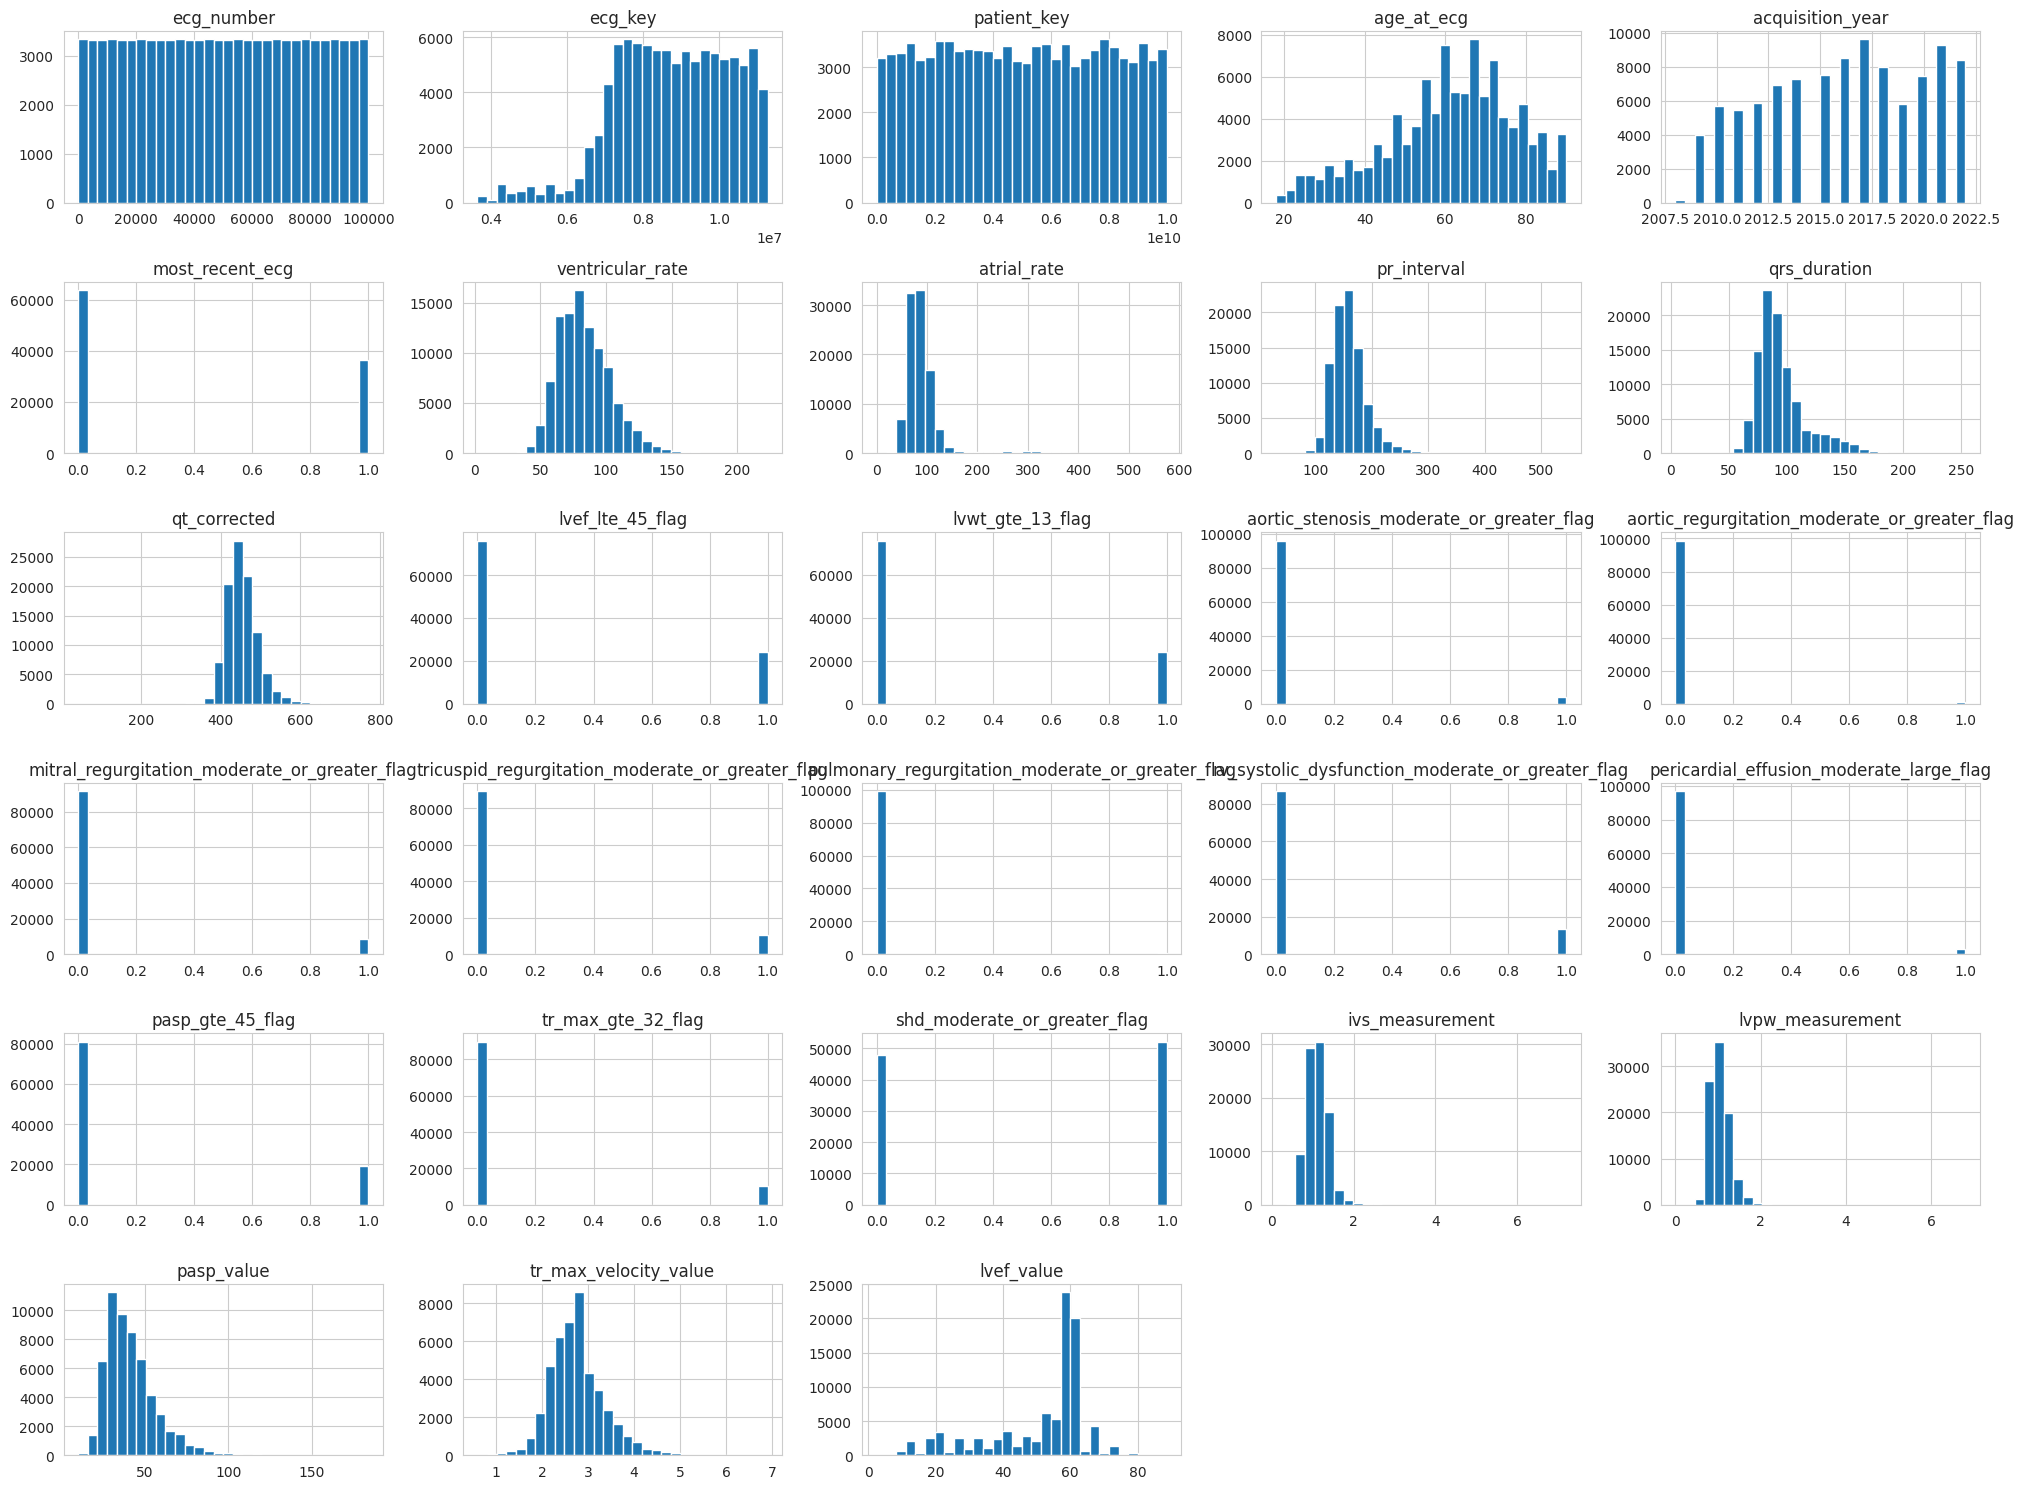

In [21]:
# histogramme
meta[numerical_cols].hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

*Interprétation*
* `ecg_number` & `patient_key` : Distribution parfaitement uniforme et plate. Confirme le statut d'identifiants numériques ou de compteurs séquentiels sans signification statistique.
* **`ecg_key`** : Distribution asymétrique vers la gauche avec un pic soudain après $0.6 \times 10^7$. Indique un changement ou une rupture dans le système d'indexation des clés d'ECG au fil du temps.
* **`age_at_ecg`** : Distribution quasi-normale, légèrement asymétrique vers la gauche. La population étudiée est principalement adulte et âgée, centrée autour de 60-70 ans, avec une baisse rapide sous la barre des 40 ans.
* **`acquisition_year`** : Distribution par paliers croissants de 2010 à 2022. Reflette une augmentation progressive du volume de données collectées au fil des années, avec une stabilisation ou un léger recul sur les dernières années.
* **Variables binaires / `_flag` (ex: `lvef_lte_45_flag`, `pulmonary_regurgitation...`, `shd_moderate_or_greater_flag`)** : Graphiques présentant uniquement deux barres distinctes à 0 et 1. La barre du 0 est massivement dominante, ce qui confirme la rareté extrême de ces pathologies (regurgitations, dysfonctions, épanchements) au sein de la cohorte. L'exception notable est `shd_moderate_or_greater_flag` où la proportion de 1 est beaucoup plus équilibrée (proche de 50%).
* **`most_recent_ecg`** : Variable binaire (0 ou 1) montrant qu'environ un tiers des examens de la base de données correspondent au dernier ECG enregistré pour un patient donné.
* `ventricular_rate`, `tr_max_velocity_value` & `qt_corrected**` : Distributions en cloche (normales) bien centrées. Elles possèdent une traîne fine vers la droite, indiquant un comportement physiologique standard pour la majorité de la population avec quelques cas de tachycardie ou d'intervalles QT allongés.
* `atrial_rate`, `pr_interval`, `qrs_duration` & `pasp_value**` : Forte concentration des données sur des valeurs basses et présence d'une longue traîne asymétrique s'étirant vers la droite. Témoigne de la présence de valeurs extrêmes isolées (valeurs aberrantes ou pathologies aiguës comme l'hypertension pulmonaire sévère pour `pasp_value`).
* `ivs_measurement` & `lvpw_measurement**` : Profils de distribution identiques et très resserrés entre 0.5 et 2, avec une asymétrie positive nette. La quasi-totalité des mesures d'épaisseur du septum et de la paroi postérieure sont concentrées dans les normes physiologiques, avec de très rares cas d'hypertrophie.
* **`lvef_value`** : Distribution asymétrique vers la gauche (étalée à gauche). Le pic principal se situe entre 55% et 65%, ce qui correspond à une fraction d'éjection normale pour une population saine, tandis que la traîne à gauche représente les patients souffrant d'insuffisance cardiaque à fraction d'éjection réduite.

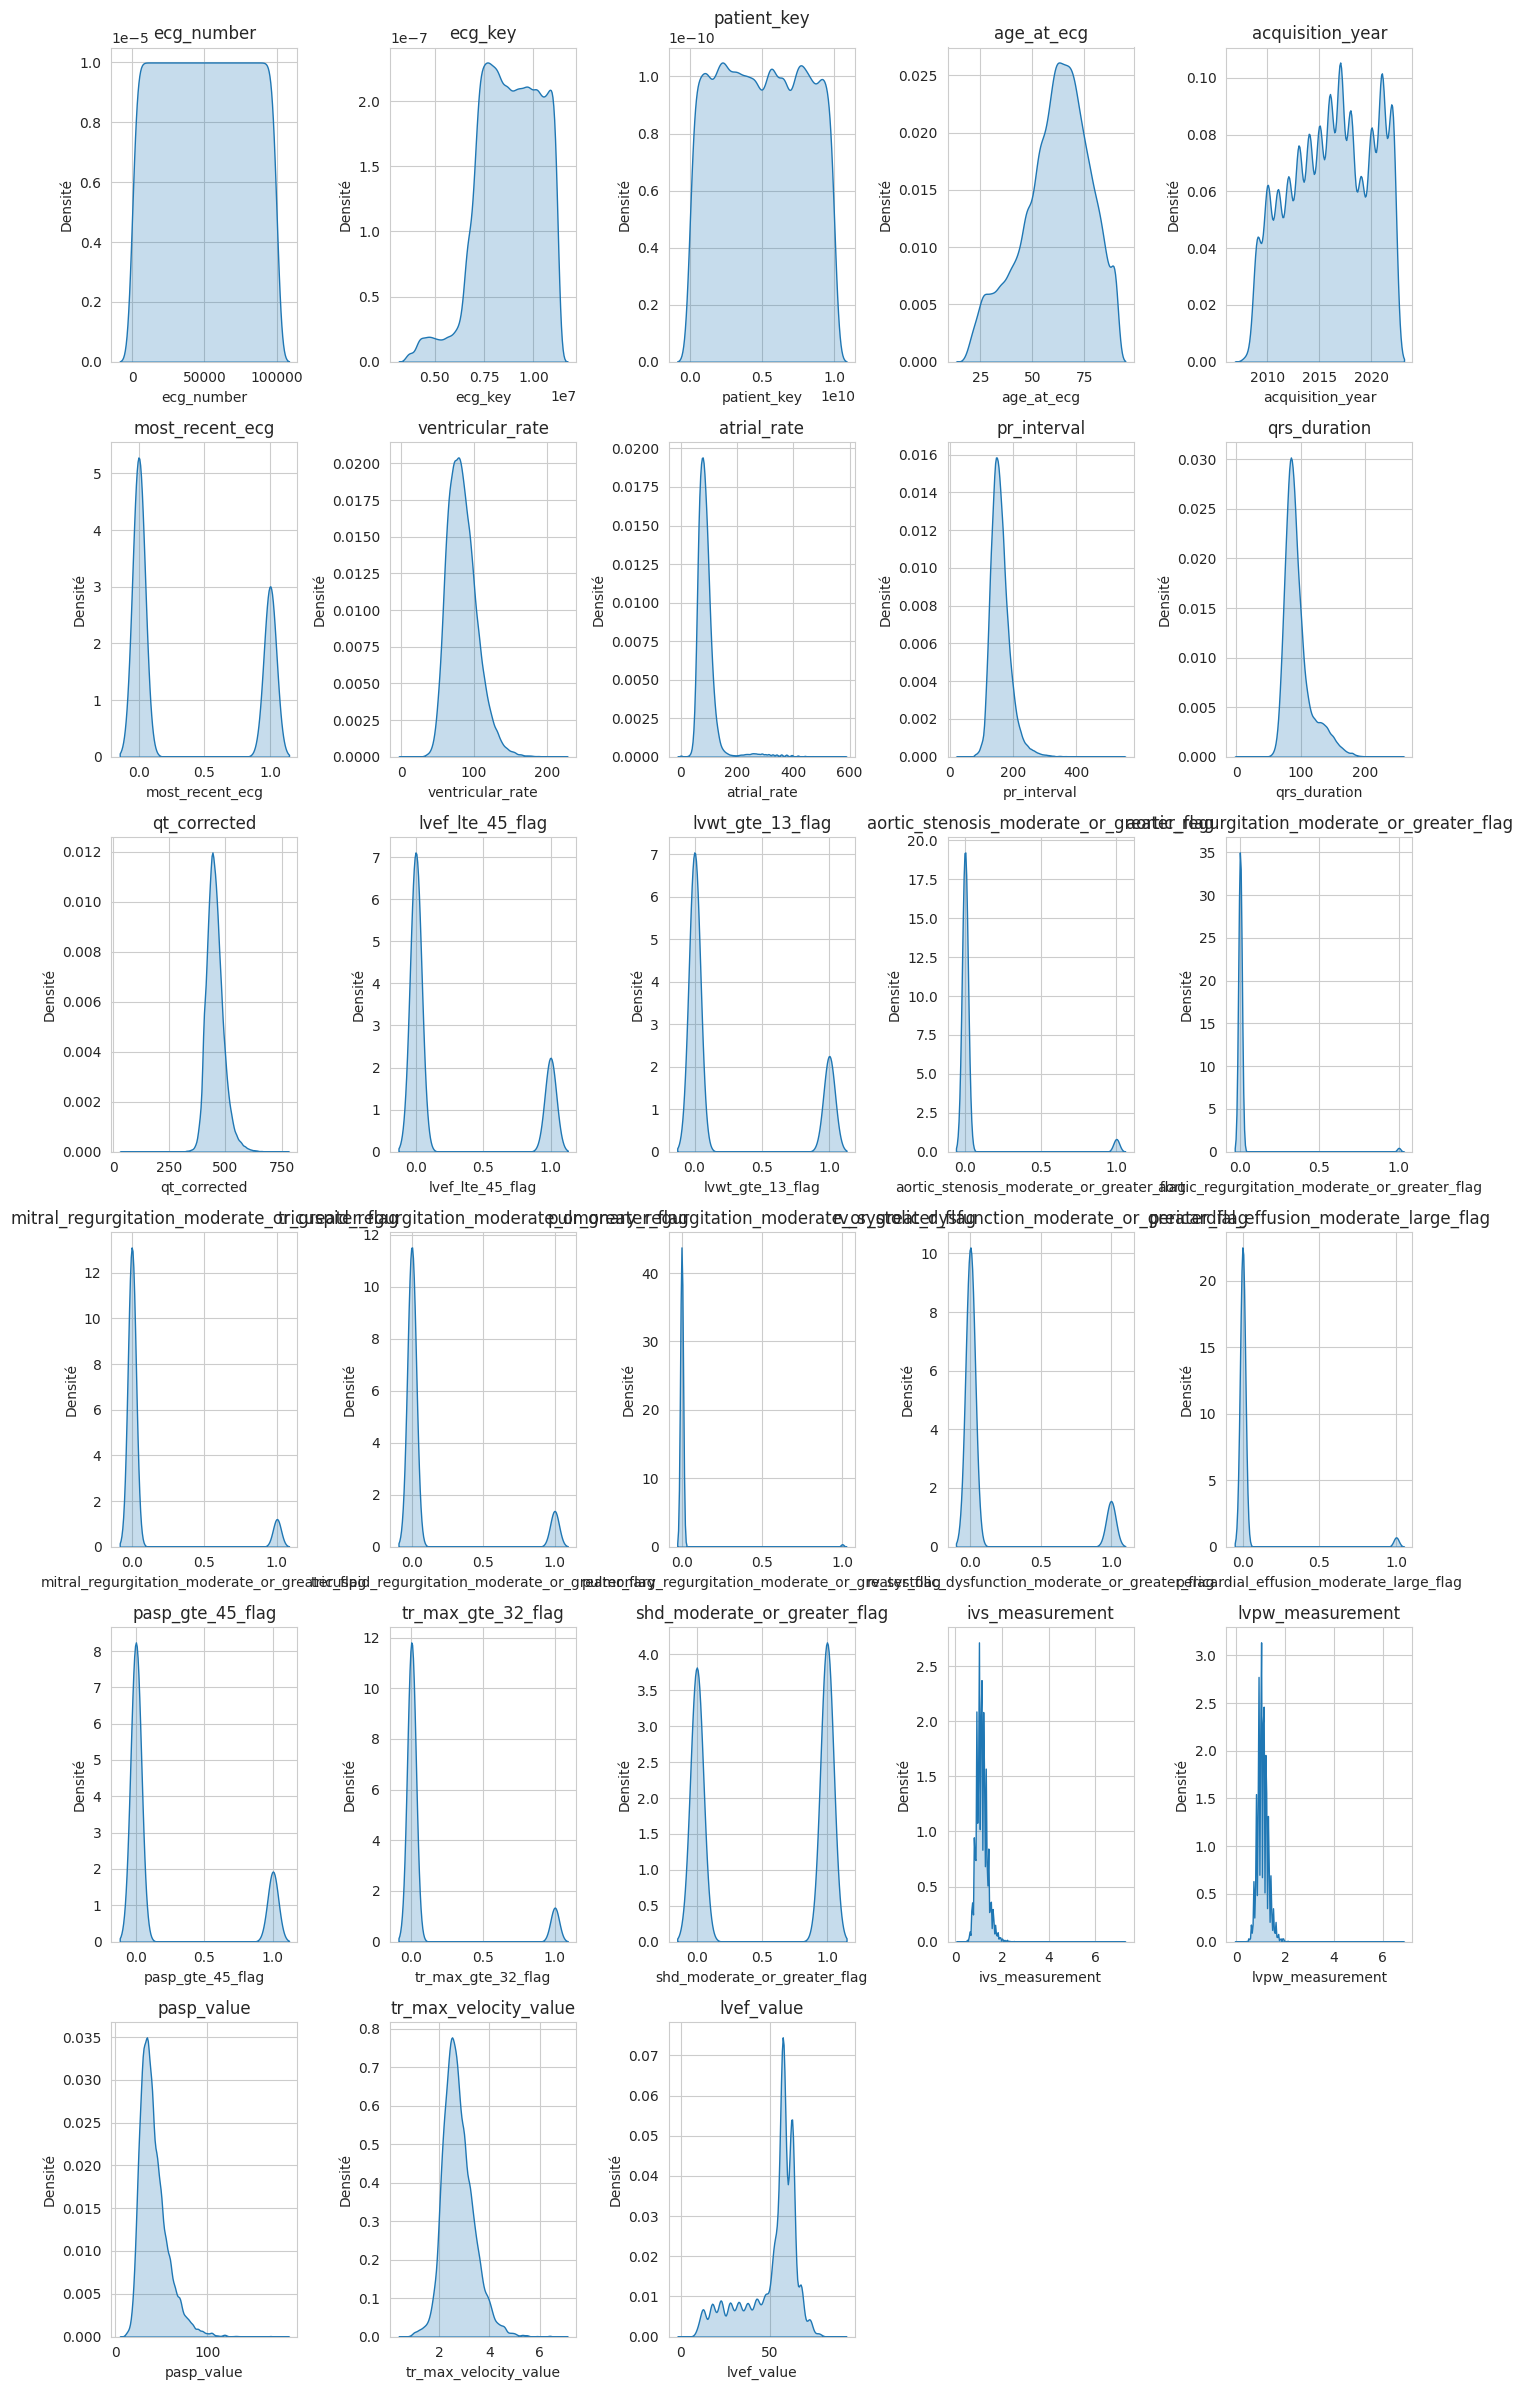

In [22]:
#densité
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols_to_plot = numerical_cols

n_cols = 5
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.kdeplot(
        meta[col].dropna(),
        fill=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('Densité')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

La courbe de densité (KDE) lisse l'histogramme pour montrer la distribution continue des données et estimer la probabilité qu'une variable prenne une valeur donnée. Elle permet de repérer instantanément la symétrie, le nombre de pics (modes) et l'étalement des valeurs.

* **Variables d'identification (`ecg_number`, `patient_key`)** : Courbes plates et rectangulaires. Confirment une distribution uniforme où chaque valeur ou plage de valeurs apparaît avec la même fréquence.
* **Variables temporelles et d'index (`ecg_key`, `acquisition_year`)** : Profils asymétriques et irréguliers. Montrent une accumulation des enregistrements au fil du temps, particulièrement visible par la croissance des courbes vers les années récentes et les index élevés.
* **Variables démographiques (`age_at_ecg`)** : Courbe unimodale, centrée et légèrement décalée vers la droite. Indique une population de patients principalement âgée (pic entre 60 et 75 ans).
* **Variables binaires (`_flag`, `most_recent_ecg`)** : Profils bimodaux avec deux cloches distinctes isolées à 0 et 1. La disproportion des hauteurs de pics illustre visuellement la rareté des pathologies (pics à 0 géants), à l'exception de `shd_moderate_or_greater_flag` où les deux bosses sont presque équilibrées.
* **Signaux et intervalles standards (`ventricular_rate`, `qt_corrected`)** : Courbes en cloche hautement symétriques. Traduisent une distribution quasi-normale centrée sur les valeurs physiologiques standards de la cohorte.
* **Variables de mesures et de pressions (`atrial_rate`, `pr_interval`, `qrs_duration`, `pasp_value`, `tr_max_velocity_value`)** : Courbes très pointues à gauche avec une longue traîne (queue) qui s'écrase lentement vers la droite. Révèlent que la majorité des patients ont des constantes basses ou normales, mais qu'une minorité présente des valeurs pathologiques très élevées.
* **Épaisseurs de parois (`ivs_measurement`, `lvpw_measurement`)** : Pics extrêmement fins et resserrés autour de 1. Démontrent une très faible variabilité inter-patients pour ces mesures structurelles, le reste de l'axe X restant vide.
* **Fraction d'éjection (`lvef_value`)** : Pic principal abrupt situé à droite (autour de 55-60%) précédé d'un étalement progressif vers la gauche. Confirme visuellement que la majorité de la cohorte possède une fonction systolique préservée, tandis que la pente douce à gauche quantifie la proportion de patients en insuffisance cardiaque.


# Détection des valeurs aberrantes

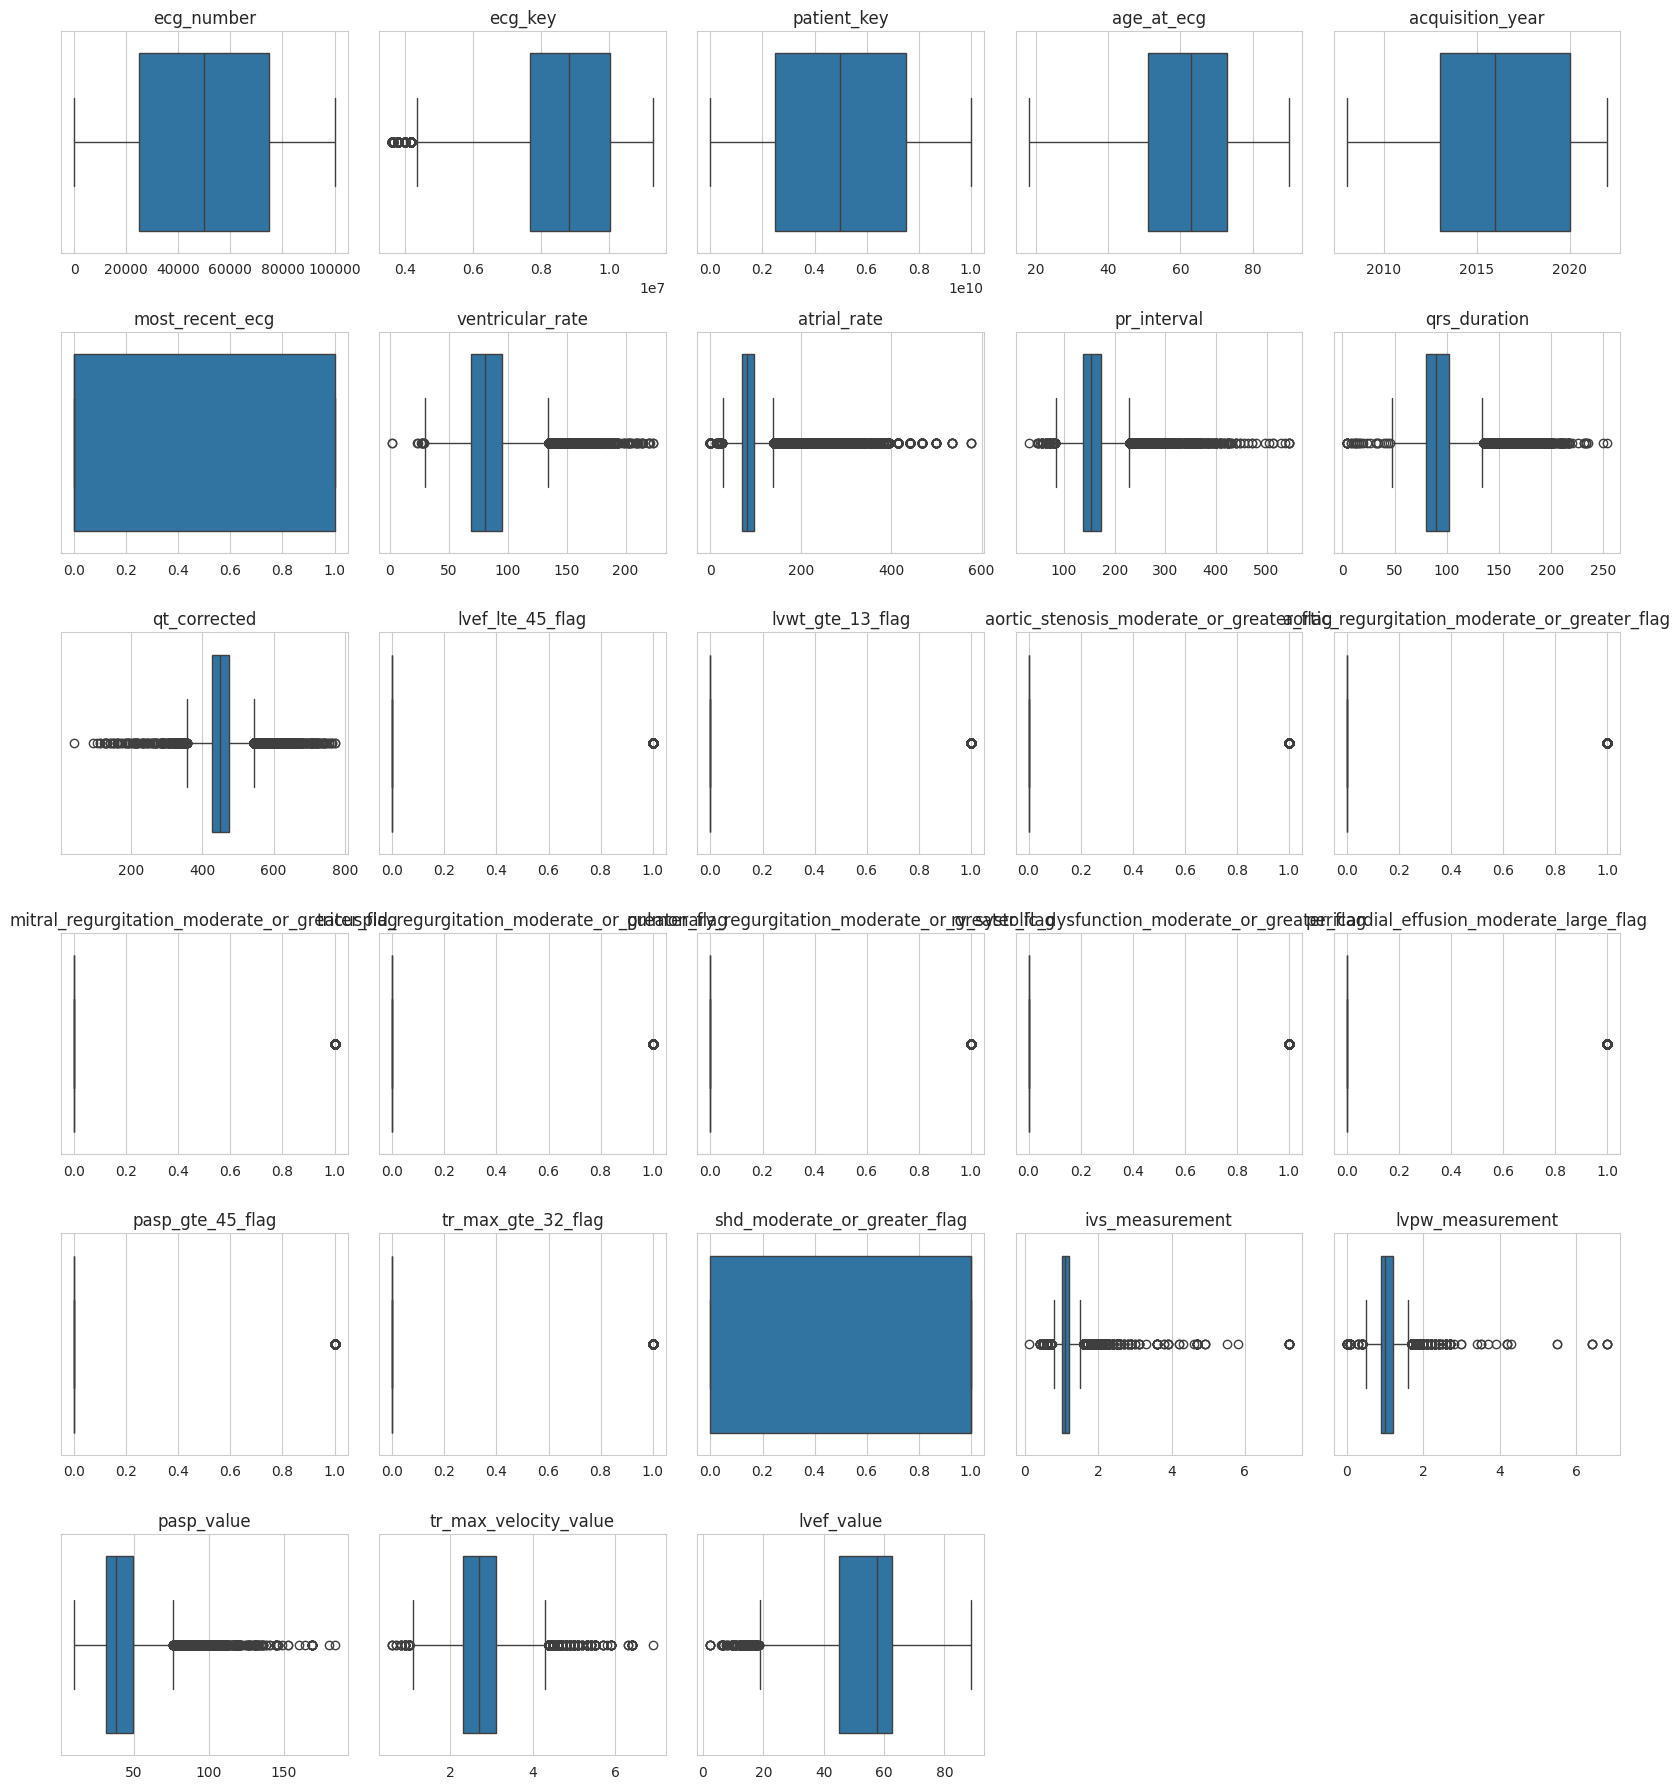

In [23]:
#boxplots
import math

n_cols = 5
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=meta[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Stratégie

La méthode de l'Écart Interquartile (IQR):

Bloc A : Le Plafonnement (Clipping) : Variables concernées : Les mesures physiques (ivs_measurement, lvpw_measurement) et les constantes ECG standards (ventricular_rate, qt_corrected)=> Si une valeur dépasse la Borne Supérieure, on ne supprime pas la ligne (pour ne pas perdre de patients). À la place, on remplace cette valeur extrême par la valeur de la borne supérieure elle-même.

Bloc B : La Conservation Clinique (Pas de suppression): Variables concernées : Les pressions et marqueurs de sévérité (pasp_value, atrial_rate, pr_interval, qrs_duration)=> En cardiologie, un patient avec une pasp_value ou un atrial_rate extrêmement élevé n'est pas une "erreur", c'est un patient en insuffisance cardiaque sévère ou aiguë.

In [24]:
#Nombre d'outliers (IQR)
outliers = {}

for col in numerical_cols:

    Q1 = meta[col].quantile(0.25)
    Q3 = meta[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    n_outliers = (
        (meta[col] < lower) |
        (meta[col] > upper)
    ).sum()

    outliers[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(
    outliers,
    orient='index',
    columns=['Outliers']
)

outlier_df.sort_values(
    by='Outliers',
    ascending=False
)

,Outliers
lvwt_gte_13_flag,24220
lvef_lte_45_flag,23892
pasp_gte_45_flag,18993
rv_systolic_dysfunction_moderate_or_greater_flag,13243
tricuspid_regurgitation_moderate_or_greater_flag,10651
tr_max_gte_32_flag,10212
mitral_regurgitation_moderate_or_greater_flag,8451
ivs_measurement,7336
qrs_duration,7304
lvef_value,5660


# Analyse des variables catégorielles

In [25]:
# cardinalité
cardinality = pd.DataFrame({
    'Unique Values': meta[categorical_cols].nunique()
})

cardinality.sort_values(
    by='Unique Values',
    ascending=False
)

,Unique Values
race_ethnicity,6
aortic_regurgitation_value,5
aortic_stenosis_value,5
pulmonary_regurgitation_value,5
pericardial_effusion_value,5
mitral_regurgitation_value,5
tricuspid_regurgitation_value,5
rv_systolic_function_value,4
location_setting,4
split,4


* **Variables démographiques de base (`sex`, `race_ethnicity`)** : `sex` ne possède que 2 valeurs uniques (catégorisation binaire homme/femme), tandis que `race_ethnicity` contient 6 catégories distinctes, ce qui permet une analyse par sous-groupes ethniques de la cohorte.
* **Variables d'évaluation clinique standardisées (`aortic_regurgitation_value`, `aortic_stenosis_value`, `pulmonary_regurgitation_value`, `pericardial_effusion_value`, `mitral_regurgitation_value`, `tricuspid_regurgitation_value`)** : Présentent toutes exactement 5 valeurs uniques. Cela indique l'utilisation d'une échelle de gradation clinique semi-quantitative standardisée.
* **Fonction ventriculaire droite (`rv_systolic_function_value`)** : Possède 4 valeurs uniques. Traduit une échelle de gradation légèrement plus restreinte pour qualifier le degré de dysfonction du ventricule droit .
* **Variables de structure des données (`location_setting`, `split`)** : `split` possède 4 valeurs uniques, correspondant au découpage des données pour la modélisation (ex: Train, Validation, Test, no split). `location_setting` comporte également 4 modalités, indiquant que les données proviennent de 4 types d'environnements cliniques ou centres hospitaliers différents.

In [26]:
# Valeurs les plus fréquentes
for col in categorical_cols:

    print("\n")
    print("="*50)
    print(col)

    print(
        meta[col]
        .value_counts()
        .head(10)
    )



sex
sex
male      53581
female    46419
Name: count, dtype: int64


location_setting
location_setting
inpatient     48162
emergency     31453
outpatient    17194
procedural     3191
Name: count, dtype: int64


race_ethnicity
race_ethnicity
hispanic    31013
white       29211
black       16461
unknown     12458
other        7429
asian        3428
Name: count, dtype: int64


aortic_stenosis_value
aortic_stenosis_value
none             77518
presumed none     6561
mild              2864
severe            2197
moderate          1857
Name: count, dtype: int64


aortic_regurgitation_value
aortic_regurgitation_value
none             75787
mild             12442
presumed none     1504
moderate          1113
severe             151
Name: count, dtype: int64


mitral_regurgitation_value
mitral_regurgitation_value
none             51912
mild             30164
moderate          7331
severe            1120
presumed none      473
Name: count, dtype: int64


tricuspid_regurgitation_value
tricuspid_r

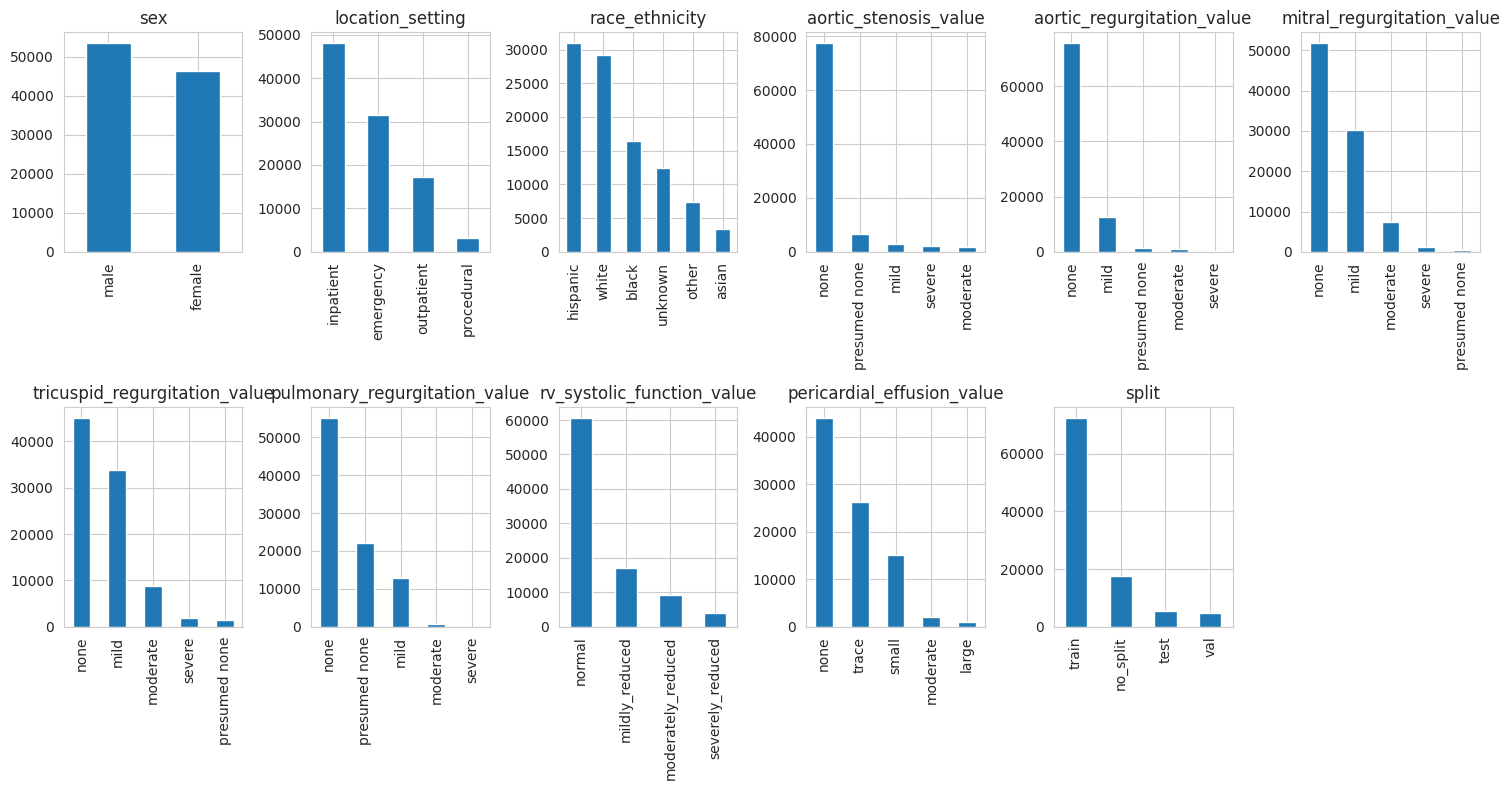

In [27]:
import math


cols_to_plot = categorical_cols

n_cols = 6
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    meta[col].value_counts().head(10).plot(
        kind='bar', 
        ax=axes[i] 
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')  
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* **`sex`** : Distribution relativement équilibrée entre les deux catégories, avec une légère prédominance d'hommes (`male`) par rapport aux femmes (`female`) dans la cohorte.
* **`location_setting`** : Les données proviennent majoritairement de patients hospitalisés (`inpatient`), suivis des urgences (`emergency`) et des consultations externes (`outpatient`). Le cadre interventionnel (`procedural`) est très minoritaire.
* **`race_ethnicity`** : Les populations majoritaires sont représentées par les catégories `hispanic` et `white`. Les catégories `black` et `unknown` occupent une place intermédiaire, tandis que les groupes `other` et `asian` sont les moins représentés.
* **Sténose aortique (`aortic_stenosis_value`)** : L'immense majorité des patients ne présente aucune sténose (`none`). Les cas identifiés se répartissent de manière résiduelle entre `presumed none`, `mild`, `severe` et `moderate`.
* **Régurgitation aortique (`aortic_regurgitation_value`)** : Profil similaire où l'absence de pathologie (`none`) domine massivement. La catégorie clinique la plus fréquente parmi les atteintes est le stade léger (`mild`), les stades modérés et sévères restant anecdotiques.
* **Régurgitation mitrale (`mitral_regurgitation_value`)** : Présente une distribution plus étalée. Bien que le stade `none` soit majoritaire, une part significative de la cohorte est atteinte d'une forme légère (`mild`), suivie du stade `moderate`. Les formes sévères sont très rares.
* **Régurgitation tricuspide (`tricuspid_regurgitation_value`)** : Suit une tendance proche de la mitrale avec une prévalence notable de cas non nuls. Les stades `none` et `mild` concentrent la quasi-totalité des effectifs, le stade `moderate` restant visible mais secondaire.
* **Régurgitation pulmonaire (`pulmonary_regurgitation_value`)** : L'absence de régurgitation (`none` ou `presumed none`) représente la presque totalité des observations. Le stade léger (`mild`) apparaît faiblement, tandis que les stades supérieurs sont quasi inexistants.
* **Fonction systolique ventriculaire droite (`rv_systolic_function_value`)** : La fonction est qualifiée de normale (`normal`) pour la grande majorité des patients. En cas d'altération, la baisse est principalement légère (`mildly_reduced`), suivie par les niveaux `moderately_reduced` et `severely_reduced`.
* **Épanchement péricardique (`pericardial_effusion_value`)** : L'absence d'épanchement (`none`) est prédominante. On observe néanmoins un gradient décroissant net et progressif sur les stades physiologiques : les formes traces (`trace`) et petites (`small`) sont fréquentes, tandis que les épanchements modérés ou larges (`large`) sont très rares.

# Corrélations

In [28]:
corr = meta[numerical_cols].corr()

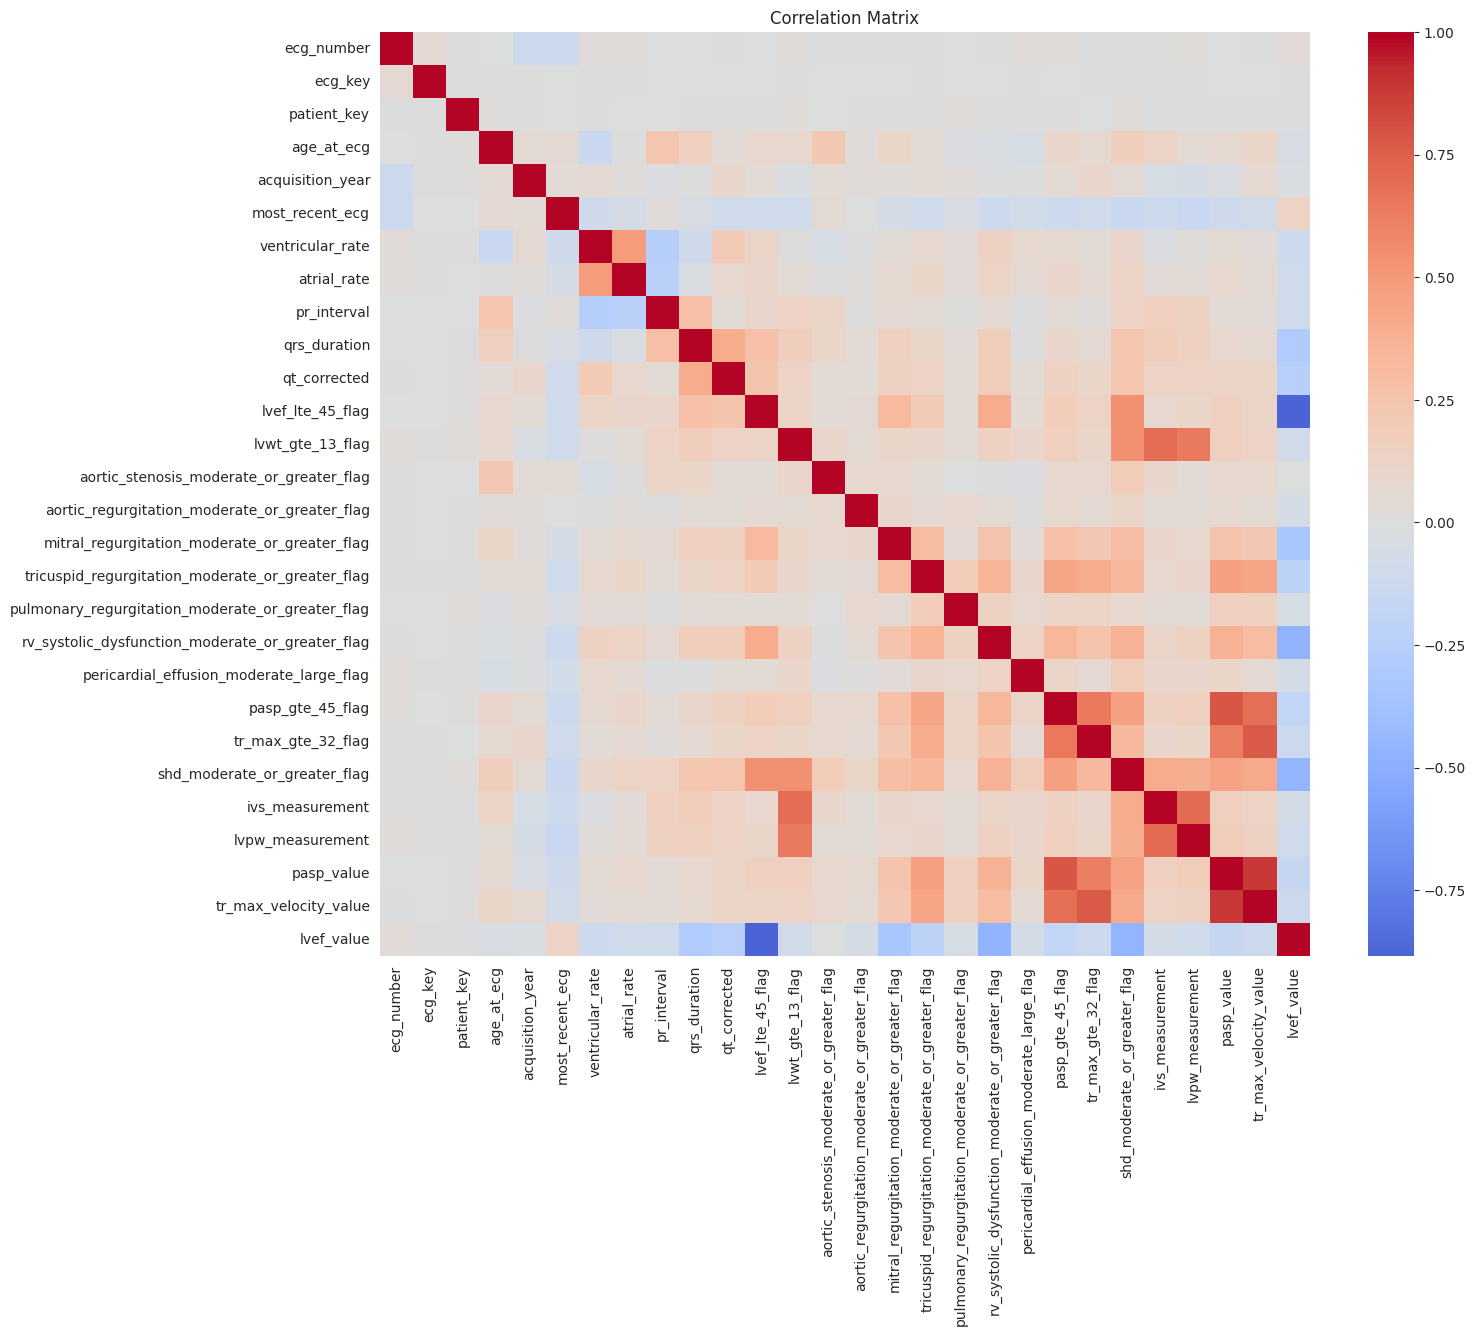

In [29]:
# heatmap 
plt.figure(figsize=(15,12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Voici les blocs de variables qui affichent les plus fortes corrélations (positives ou négatives) visibles sur la matrice :

* **`pasp_value` & `tr_max_velocity_value` (Forte corrélation positive / Rouge foncé)** : Corrélation physiologique directe très marquée. La vitesse maximale de régurgitation tricuspide (`tr_max_velocity_value`) sert cliniquement à calculer la pression artérielle systolique pulmonaire (`pasp_value`).
* **`pasp_gte_45_flag` & `tr_max_gte_32_flag` (Forte corrélation positive / Rouge foncé)** : Corrélation logique entre deux seuils cliniques dépendants. Ils sont également tous deux fortement corrélés de manière positive avec leurs variables continues respectives (`pasp_value` et `tr_max_velocity_value`).
* **`ivs_measurement` & `lvpw_measurement` (Forte corrélation positive / Rouge)** : Corrélation structurelle logique. L'épaisseur du septum interventriculaire (`ivs`) évolue proportionnellement avec celle de la paroi postérieure du ventricule gauche (`lvpw`) en cas d'hypertrophie cardiaque.
* **`lvwt_gte_13_flag` avec `ivs_measurement` & `lvpw_measurement` (Forte corrélation positive / Rouge)** : Le flag d'hypertrophie (`lvwt_gte_13_flag`) est directement corrélé aux mesures continues des parois cardiaques qui servent à le définir.
* **`lvef_value` & `lvef_lte_45_flag` (Forte corrélation négative / Bleu foncé)** : Corrélation inverse mathématique parfaite. Plus la valeur continue de la fraction d'éjection (`lvef_value`) baisse, plus le flag indiquant une FEVG inférieure ou égale à 45% passe à 1.
* **`ventricular_rate` & `atrial_rate` (Corrélation positive modérée à forte / Orange-Rouge)** : Association rythmologique attendue où le rythme des ventricules suit généralement le rythme des oreillettes.
* **`shd_moderate_or_greater_flag` avec les variables de régurgitations / dysfonctions (Corrélation positive modérée / Orange)** : Ce flag global de cardiopathie structurelle (`shd`) montre une corrélation diffuse avec plusieurs atteintes spécifiques (mitrale, tricuspide, dysfonction VD).

In [30]:
# Variables fortement corrélées
corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.70)
]

print(high_corr)

['lvpw_measurement', 'pasp_value', 'tr_max_velocity_value', 'lvef_value']


# Nettoyage des méta données

**C2 — Gestion NaN (sans suppression ni imputation naïve)**

In [31]:
# COPIE SECURISEE DES DONNEES

df_native = meta.copy(deep=True)
df_model = meta.copy(deep=True)


In [32]:
# C2 — Gestion NaN (sans suppression ni imputation naïve)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. TRAITEMENT DES VARIABLES ÉCHOGRAPHIQUES CATÉGORIELLES
#    (NaN cliniquement = absence de pathologie → 'none' / 'normal')
echo_categorical = [
    "aortic_stenosis_value",
    "mitral_regurgitation_value",
    "tricuspid_regurgitation_value",
    "pulmonary_regurgitation_value",
    "rv_systolic_function_value",
    "pericardial_effusion_value"
]

for col in echo_categorical:
    if col not in df_model.columns:
        continue
    fill_val = "normal" if col == "rv_systolic_function_value" else "none"
    df_model[col] = df_model[col].fillna(fill_val)

# 2. IMPUTATION MICE (IterativeImputer)
#    Variables numériques avec manque structurel
predictor_vars = [
    # démographie
    "age_at_ecg",
    # variables à imputer
    "lvef_value",
    "pasp_value",
    "tr_max_velocity_value",
    "ivs_measurement",
    "lvpw_measurement",
    "pr_interval",
    "atrial_rate",
    # variables auxiliaires XGBoost (bien observées)
    "lvwt_gte_13_flag",
    "pasp_gte_45_flag",
    "rv_systolic_dysfunction_moderate_or_greater_flag",
    "mitral_regurgitation_moderate_or_greater_flag",
    "shd_moderate_or_greater_flag"
]

predictor_vars = [c for c in predictor_vars if c in df_model.columns]

print("Début imputation MICE...")
imputer = IterativeImputer(random_state=42, max_iter=20, sample_posterior=True)
df_model[predictor_vars] = imputer.fit_transform(df_model[predictor_vars])
print("Imputation terminée.")

# 3. CONTRAINTES PHYSIOLOGIQUES (post-imputation)
physiological_clips = {
    "lvef_value"            : (5,   90),
    "pasp_value"            : (10, 120),
    "tr_max_velocity_value" : (1.0, 6.0),
    #"ivs_measurement"       : (5,   30),
    #"lvpw_measurement"      : (5,   30),
    "pr_interval"           : (80, 400),
    "atrial_rate"           : (20, 250),
}

for col, (lo, hi) in physiological_clips.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].clip(lo, hi)

# 4. CONTRÔLE QUALITÉ
missing_after = df_model.isna().sum().sort_values(ascending=False)
remaining     = missing_after[missing_after > 0]

print("\nNaN restants :")
if remaining.empty:
    print("   Aucune valeur manquante.")
else:
    display(remaining)

print(f"\nShape finale : {df_model.shape}")
print(f"NaN totaux   : {df_model.isna().sum().sum()}")

Début imputation MICE...
Imputation terminée.

NaN restants :


aortic_regurgitation_value    9003
qt_corrected                     1
dtype: int64


Shape finale : (100000, 39)
NaN totaux   : 9004


In [33]:
df_model["aortic_regurgitation_value"].value_counts(dropna=False)

aortic_regurgitation_value
none             75787
mild             12442
NaN               9003
presumed none     1504
moderate          1113
severe             151
Name: count, dtype: int64

In [34]:
df_model["aortic_regurgitation_value"] = (
    df_model["aortic_regurgitation_value"]
    .fillna(df_model["aortic_regurgitation_value"].mode()[0])
)

In [35]:
#Par colonne
missing = pd.DataFrame({
    'Missing Count': df_model .isnull().sum(),
    'Missing %': round(df_model .isnull().mean()*100,2)
})

missing = missing.sort_values(
    by='Missing %',
    ascending=False
)

missing

,Missing Count,Missing %
ecg_number,0,0.0
ecg_key,0,0.0
patient_key,0,0.0
age_at_ecg,0,0.0
sex,0,0.0
acquisition_year,0,0.0
location_setting,0,0.0
race_ethnicity,0,0.0
most_recent_ecg,0,0.0
ventricular_rate,0,0.0


**C3 — Traitement des outliers (IQR-based)**

In [36]:
# ============================================================
# C3 — TRAITEMENT DES VALEURS ABERRANTES (IQR)
# ============================================================
# Variables traitées par clipping IQR :
#
# ivs_measurement       → erreurs de mesure écho
# lvpw_measurement      → erreurs de mesure écho
# qt_corrected          → artefacts d'extraction ECG
# qrs_duration          → artefacts d'extraction ECG
# ventricular_rate      → artefacts d'extraction ECG
#
# Justification :
# - Ces variables sont sensibles aux erreurs de mesure,
#   erreurs d'extraction ou erreurs de saisie.
# - Des valeurs extrêmement élevées sont souvent
#   physiologiquement peu plausibles.
# - On préfère plafonner plutôt que supprimer les lignes.
#
# Variables NON traitées :
#
# lvef_value            → IC sévère (FEVG < 10% possible)
# pasp_value            → HTAP sévère (> 80 mmHg réel)
# atrial_rate           → flutter/fibrillation (valeurs extrêmes réelles)
# pr_interval           → blocs AV sévères (valeurs extrêmes réelles)
# tr_max_velocity_value → HTAP sévère (signal clinique fort)
#
# Justification :
# - Les valeurs extrêmes peuvent correspondre à des cas
#   cliniques réels (IC sévère, HTAP sévère, flutter,
#   fibrillation, troubles de conduction, etc.).
# - Les modifier risquerait d'atténuer le signal clinique
#   utile à la détection précoce de l'insuffisance cardiaque.
#
# Variables binaires (_flag) :
# - Aucun traitement.
# - Les "outliers" détectés par IQR sur des variables 0/1
#   sont des artefacts mathématiques sans signification.
#
# Variables identifiants (ecg_key, patient_key, ecg_number) :
# - Aucun traitement.
# ============================================================

clip_cols = [
   # 'ivs_measurement',
    #'lvpw_measurement',
    'qt_corrected',
    'qrs_duration',    
    'ventricular_rate', # valeurs > 300 bpm non physiologiques
]

for col in clip_cols:
    if col not in df_model.columns:
        continue
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = (
        ((df_model[col] < lower) | (df_model[col] > upper))
        .sum()
    )
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)
    print(
        f"{col}: {n_outliers} outliers plafonnés "
        f"→ [{lower:.2f}, {upper:.2f}]"
    )

print("\nTraitement des outliers terminé sur df_model.")

qt_corrected: 2778 outliers plafonnés → [356.50, 544.50]
qrs_duration: 7304 outliers plafonnés → [47.00, 135.00]
ventricular_rate: 1780 outliers plafonnés → [30.00, 134.00]

Traitement des outliers terminé sur df_model.


In [37]:
#Nombre d'outliers (IQR)
outliers = {}

for col in numerical_cols:

    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    n_outliers = (
        (df_model[col] < lower) |
        (df_model[col] > upper)
    ).sum()

    outliers[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(
    outliers,
    orient='index',
    columns=['Outliers']
)

outlier_df.sort_values(
    by='Outliers',
    ascending=False
)

,Outliers
lvwt_gte_13_flag,24220
lvef_lte_45_flag,23892
pasp_gte_45_flag,18993
rv_systolic_dysfunction_moderate_or_greater_flag,13243
tricuspid_regurgitation_moderate_or_greater_flag,10651
tr_max_gte_32_flag,10212
mitral_regurgitation_moderate_or_greater_flag,8451
lvef_value,5759
atrial_rate,4741
pr_interval,4740


**C1 — Encodage one-hot**

In [38]:
# C1 — GESTION NaN CATÉGORIELLES + ENCODAGE ORDINAL

#  ÉTAPE 1 : fillna AVANT encodage 
echo_categorical_fills = {
    'aortic_stenosis_value'        : 'none',
    'aortic_regurgitation_value'   : 'none',
    'mitral_regurgitation_value'   : 'none',
    'tricuspid_regurgitation_value': 'none',
    'pulmonary_regurgitation_value': 'none',
    'rv_systolic_function_value'   : 'normal',
    'pericardial_effusion_value'   : 'none',
}

for col, fill_val in echo_categorical_fills.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(fill_val)
        print(f"   {col} → NaN remplacés par '{fill_val}'")

#  ÉTAPE 2 : encodage ordinal APRÈS fillna 
regurg_order           = ['none', 'presumed none', 'mild', 'moderate', 'severe']
rv_order               = ['normal', 'mildly_reduced', 'moderately_reduced', 'severely_reduced']
pericardial_order      = ['none', 'trace', 'small', 'moderate', 'large']
sex_order              = ['female', 'male']
location_setting_order = ['inpatient', 'emergency', 'outpatient', 'procedural']
race_ethnicity_order   = ['asian', 'black', 'hispanic', 'other', 'unknown', 'white']

ordinal_mappings = {
    'sex'                           : sex_order,
    'location_setting'              : location_setting_order,
    'race_ethnicity'                : race_ethnicity_order,
    'aortic_stenosis_value'         : regurg_order,
    'aortic_regurgitation_value'    : regurg_order,
    'mitral_regurgitation_value'    : regurg_order,
    'tricuspid_regurgitation_value' : regurg_order,
    'pulmonary_regurgitation_value' : regurg_order,
    'rv_systolic_function_value'    : rv_order,
    'pericardial_effusion_value'    : pericardial_order,
}

for col, order in ordinal_mappings.items():
    mapping = {val: idx for idx, val in enumerate(order)}
    df_model[col] = df_model[col].map(mapping)
    n_unmapped = df_model[col].isnull().sum()
    if n_unmapped > 0:
        print(f"   {col} : {n_unmapped} NaN restants")
    else:
        print(f"   {col} encodée → {mapping}")

#  ÉTAPE 3 : cast Int64 
for col in ordinal_mappings.keys():
    df_model[col] = df_model[col].astype('Int64')

#  Vérification 
encoded_cols = list(ordinal_mappings.keys())
print(f"\nNaN totaux : {df_model[encoded_cols].isnull().sum().sum()}")
print(f"\nTypes :\n{df_model[encoded_cols].dtypes}")
print(f"\nAperçu :\n{df_model[encoded_cols].head()}")
print(f"\nShape finale : {df_model.shape}")

   aortic_stenosis_value → NaN remplacés par 'none'
   aortic_regurgitation_value → NaN remplacés par 'none'
   mitral_regurgitation_value → NaN remplacés par 'none'
   tricuspid_regurgitation_value → NaN remplacés par 'none'
   pulmonary_regurgitation_value → NaN remplacés par 'none'
   rv_systolic_function_value → NaN remplacés par 'normal'
   pericardial_effusion_value → NaN remplacés par 'none'
   sex encodée → {'female': 0, 'male': 1}
   location_setting encodée → {'inpatient': 0, 'emergency': 1, 'outpatient': 2, 'procedural': 3}
   race_ethnicity encodée → {'asian': 0, 'black': 1, 'hispanic': 2, 'other': 3, 'unknown': 4, 'white': 5}
   aortic_stenosis_value encodée → {'none': 0, 'presumed none': 1, 'mild': 2, 'moderate': 3, 'severe': 4}
   aortic_regurgitation_value encodée → {'none': 0, 'presumed none': 1, 'mild': 2, 'moderate': 3, 'severe': 4}
   mitral_regurgitation_value encodée → {'none': 0, 'presumed none': 1, 'mild': 2, 'moderate': 3, 'severe': 4}
   tricuspid_regurgitatio

In [39]:
df_model.head()

,ecg_number,ecg_key,patient_key,age_at_ecg,sex,acquisition_year,location_setting,race_ethnicity,most_recent_ecg,ventricular_rate,atrial_rate,pr_interval,qrs_duration,qt_corrected,lvef_lte_45_flag,lvwt_gte_13_flag,aortic_stenosis_moderate_or_greater_flag,aortic_regurgitation_moderate_or_greater_flag,mitral_regurgitation_moderate_or_greater_flag,tricuspid_regurgitation_moderate_or_greater_flag,pulmonary_regurgitation_moderate_or_greater_flag,rv_systolic_dysfunction_moderate_or_greater_flag,pericardial_effusion_moderate_large_flag,pasp_gte_45_flag,tr_max_gte_32_flag,shd_moderate_or_greater_flag,aortic_stenosis_value,aortic_regurgitation_value,mitral_regurgitation_value,tricuspid_regurgitation_value,pulmonary_regurgitation_value,rv_systolic_function_value,pericardial_effusion_value,ivs_measurement,lvpw_measurement,pasp_value,tr_max_velocity_value,lvef_value,split
0,0,8520052,902618160,88.0,1,2014,1,3,1,117,117.0,162.000000,116,463.0,0,0.0,0,0,0.0,0,0,0.0,0,0.0,0,0.0,0,0,2,0,1,0,1,1.000000,1.000000,23.315828,1.774175,62.500000,train
1,1,7283576,4764241080,69.0,0,2019,0,1,0,99,99.0,128.000000,74,449.0,0,0.0,0,0,0.0,0,0,0.0,0,0.0,0,0.0,0,0,0,0,0,0,0,1.066302,0.880996,41.096083,2.914681,77.234856,train
2,2,8769869,4214459612,22.0,1,2017,0,5,0,86,86.0,144.000000,84,485.0,0,0.0,0,0,0.0,0,0,0.0,0,1.0,0,1.0,0,0,0,0,0,1,2,1.100000,1.100000,51.000000,3.342957,57.500000,train
3,3,6379904,6205191619,70.0,1,2022,1,2,0,68,68.0,136.000000,80,427.0,1,0.0,0,0,0.0,0,0,0.0,0,0.0,0,1.0,0,0,0,0,0,0,0,0.900000,1.000000,48.291314,2.998944,45.000000,train
4,4,9619545,8380688329,54.0,1,2013,0,3,0,90,93.0,128.636861,135,544.5,1,0.0,0,0,0.0,0,0,1.0,0,0.0,0,1.0,1,2,2,2,0,2,2,1.200000,1.000000,38.000000,2.600000,20.000000,train


         RAPPORT EDA — df_model AFTER CLEANSING

 1. SHAPE & TYPES
   Shape : 100,000 lignes × 39 colonnes
   Types :
int64      14
float64    14
Int64      10
object      1

 2. VALEURS MANQUANTES
     1 NaN restants :
qt_corrected    1

 3. STATISTIQUES DESCRIPTIVES
                                                     count              mean                std        min           25%           50%           75%           max
ecg_number                                        100000.0           49999.5       28867.657797        0.0      24999.75       49999.5      74999.25       99999.0
ecg_key                                           100000.0      8773789.5534     1516726.586223  3632711.0    7688689.75     8827948.0    10013516.0    11280435.0
patient_key                                       100000.0  4990837448.39502  2883732071.405775   146550.0  2476572135.0  4980671822.0  7507247599.0  9999852630.0
age_at_ecg                                        100000.0          61.17929   

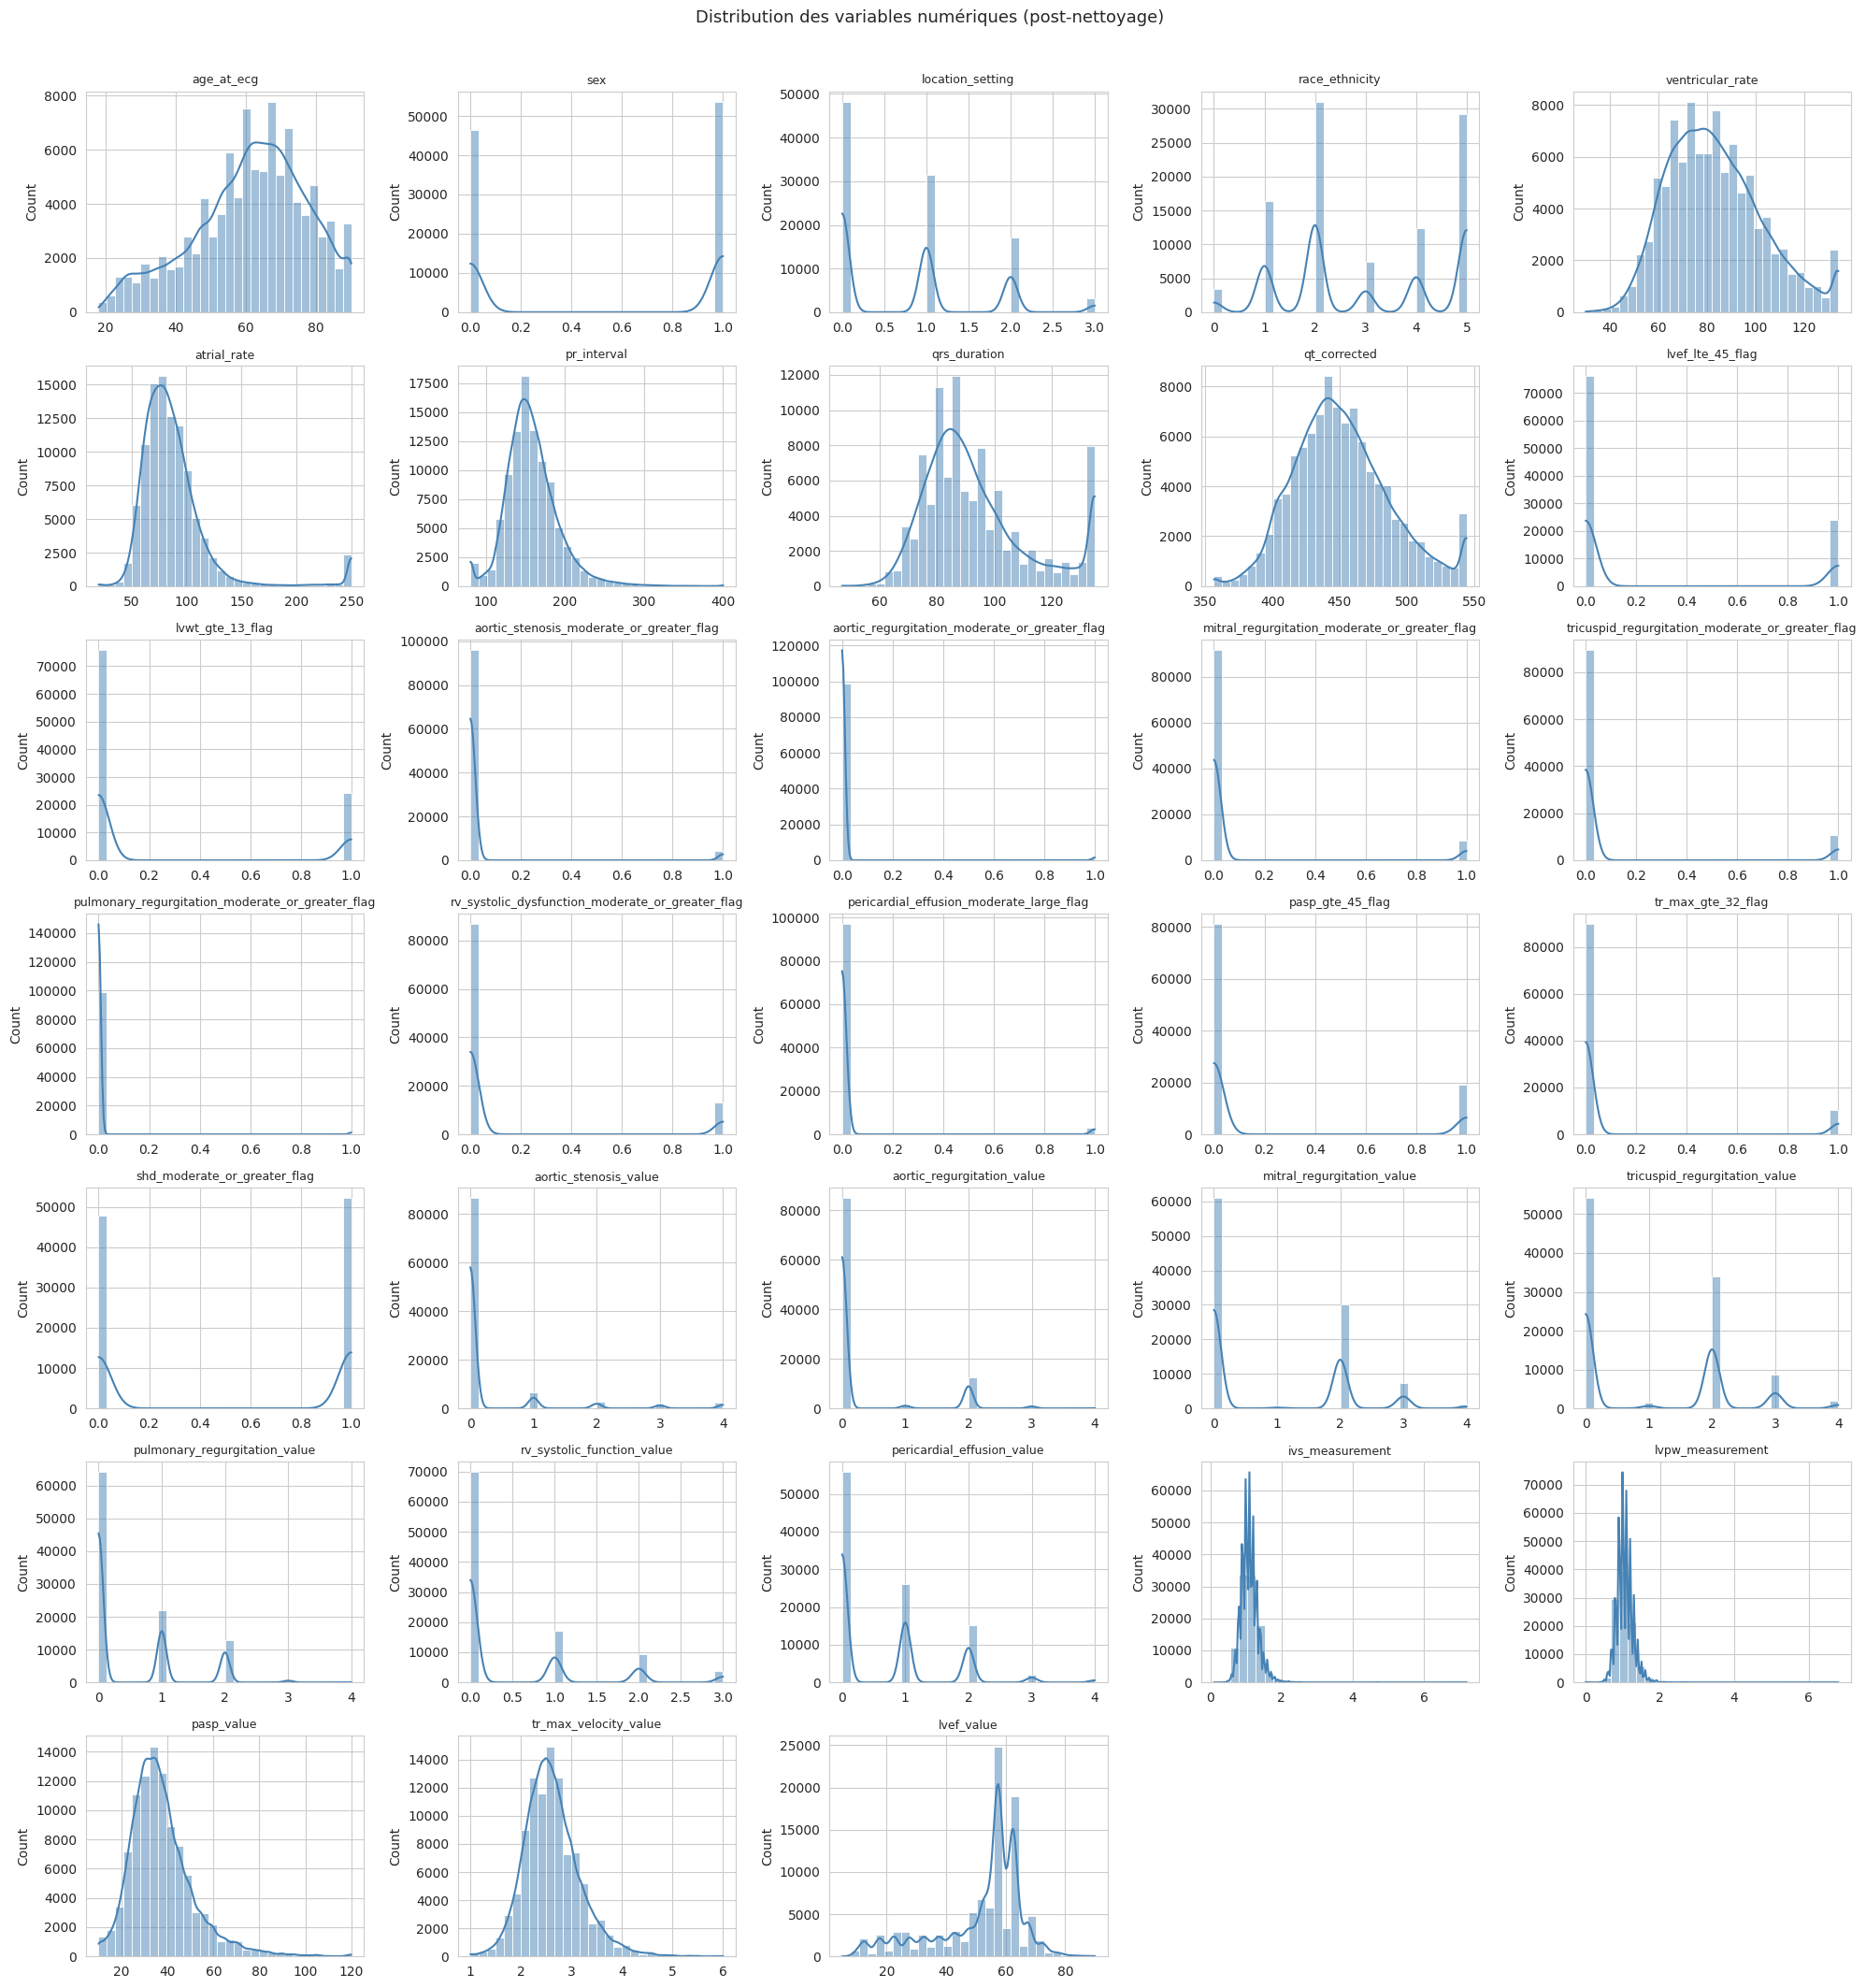

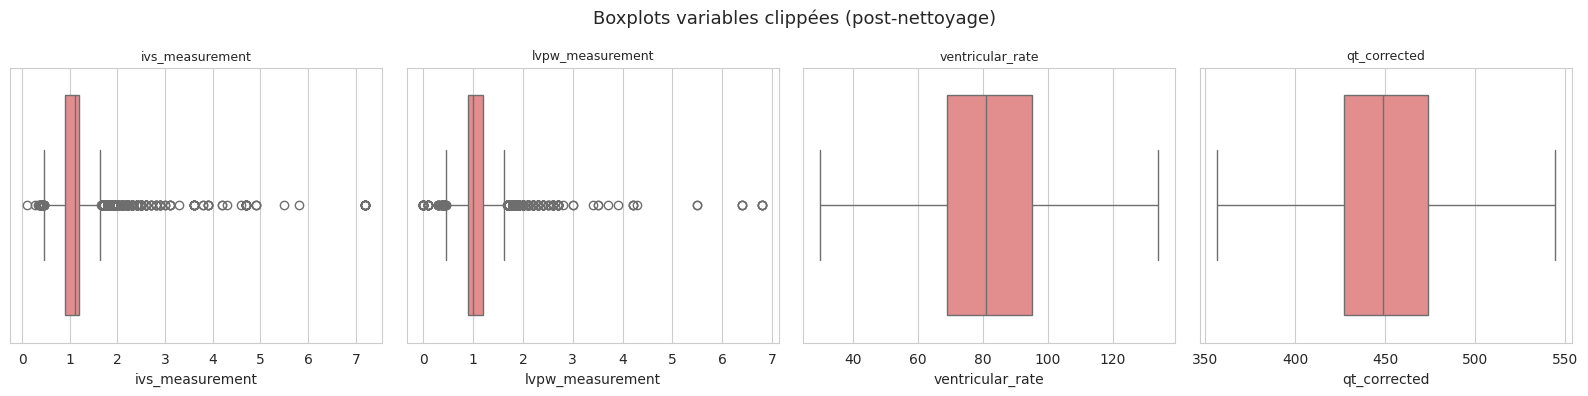


 6. VÉRIFICATION ENCODAGE ORDINAL
   sex                                      → valeurs : [np.int64(0), np.int64(1)]
   location_setting                         → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
   race_ethnicity                           → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   aortic_stenosis_value                    → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   aortic_regurgitation_value               → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   mitral_regurgitation_value               → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   tricuspid_regurgitation_value            → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   pulmonary_regurgitation_value            → valeurs : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   rv_systolic_function_valu

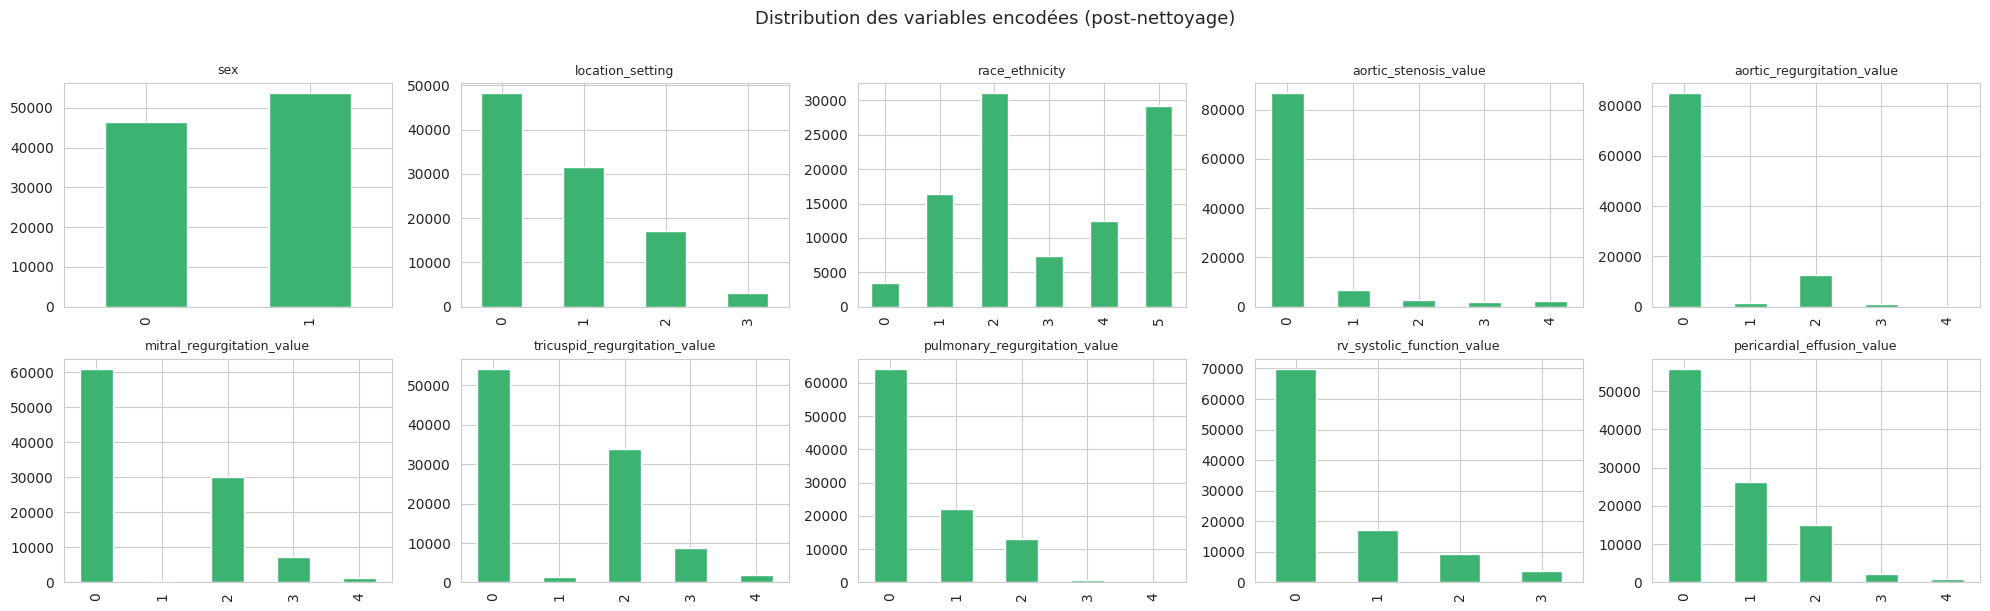

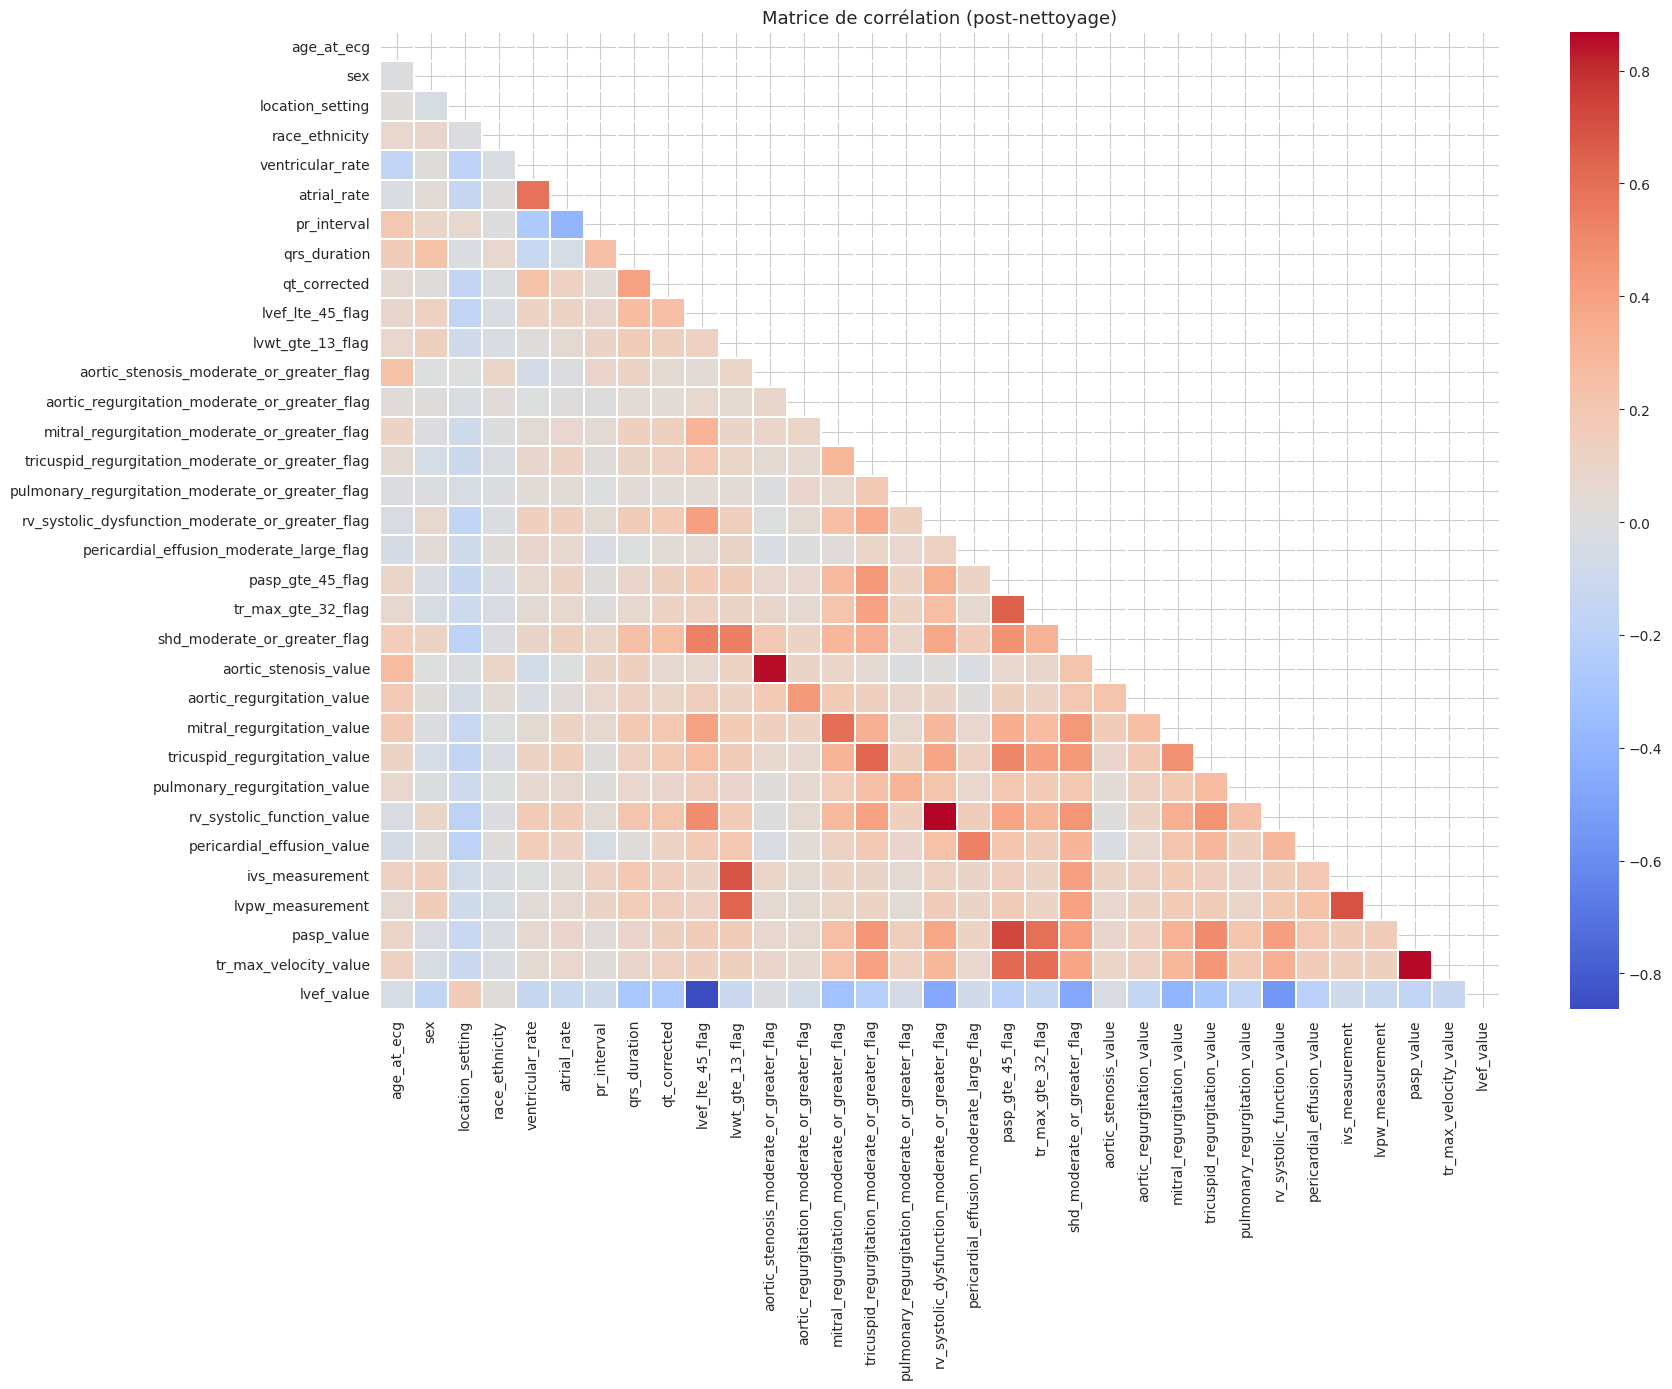


               RÉSUMÉ POST-NETTOYAGE — df_model
  Shape finale          : 100,000 lignes × 39 colonnes
  Valeurs manquantes    : 1
  Variables numériques  : 38
  Variables encodées    : 10
  Doublons              : 0


In [40]:
# RAPPORT EDA — df_model AFTER CLEANSING
import seaborn as sns
import math

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("=" * 60)
print("         RAPPORT EDA — df_model AFTER CLEANSING")
print("=" * 60)

# 1. SHAPE & TYPES
print("\n 1. SHAPE & TYPES")
print(f"   Shape : {df_model.shape[0]:,} lignes × {df_model.shape[1]} colonnes")
print(f"   Types :\n{df_model.dtypes.value_counts().to_string()}")

# 2. VALEURS MANQUANTES
print("\n 2. VALEURS MANQUANTES")
total_nan = df_model.isnull().sum().sum()
if total_nan == 0:
    print("    Aucune valeur manquante restante.")
else:
    remaining = df_model.isnull().sum()
    remaining = remaining[remaining > 0]
    print(f"     {total_nan} NaN restants :")
    print(remaining.to_string())

# 3. STATISTIQUES DESCRIPTIVES
print("\n 3. STATISTIQUES DESCRIPTIVES")
print(df_model.describe().T.to_string())

# 4. DISTRIBUTION DES VARIABLES NUMÉRIQUES
numerical_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude = ['patient_key', 'ecg_key', 'ecg_number', 'acquisition_year', 'most_recent_ecg', 'split']
plot_cols = [c for c in numerical_cols if c not in exclude]

n_cols = 5
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(df_model[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution des variables numériques (post-nettoyage)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 5. BOXPLOTS — VÉRIFICATION OUTLIERS APRÈS CLIPPING
clip_cols = [c for c in ['ivs_measurement', 'lvpw_measurement', 'ventricular_rate', 'qt_corrected']
             if c in df_model.columns]

if clip_cols:
    fig, axes = plt.subplots(1, len(clip_cols), figsize=(4 * len(clip_cols), 4))
    if len(clip_cols) == 1:
        axes = [axes]
    for i, col in enumerate(clip_cols):
        sns.boxplot(x=df_model[col], ax=axes[i], color='lightcoral')
        axes[i].set_title(col, fontsize=9)
    plt.suptitle("Boxplots variables clippées (post-nettoyage)", fontsize=13)
    plt.tight_layout()
    plt.show()

# 6. VÉRIFICATION ENCODAGE ORDINAL
print("\n 6. VÉRIFICATION ENCODAGE ORDINAL")
encoded_cols_candidates = [
    'sex', 'location_setting', 'race_ethnicity',
    'aortic_stenosis_value', 'aortic_regurgitation_value',
    'mitral_regurgitation_value', 'tricuspid_regurgitation_value',
    'pulmonary_regurgitation_value', 'rv_systolic_function_value',
    'pericardial_effusion_value'
]
encoded_cols = [c for c in encoded_cols_candidates if c in df_model.columns]

for col in encoded_cols:
    vals = sorted(df_model[col].dropna().unique())
    print(f"   {col:40s} → valeurs : {vals}")

# 7. DISTRIBUTION DES VARIABLES ENCODÉES
if encoded_cols:
    n_cols = 5
    n_rows = math.ceil(len(encoded_cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(encoded_cols):
        df_model[col].value_counts().sort_index().plot(
            kind='bar', ax=axes[i], color='mediumseagreen', edgecolor='white'
        )
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Distribution des variables encodées (post-nettoyage)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# 8. MATRICE DE CORRÉLATION
corr_cols = [c for c in numerical_cols if c not in exclude]

if len(corr_cols) > 1:
    plt.figure(figsize=(18, 14))
    corr = df_model[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr,
        mask=mask,
        cmap='coolwarm',
        center=0,
        annot=False,
        linewidths=0.3
    )
    plt.title("Matrice de corrélation (post-nettoyage)", fontsize=13)
    plt.tight_layout()
    plt.show()

# 9. RÉSUMÉ FINAL
print("\n" + "=" * 60)
print("               RÉSUMÉ POST-NETTOYAGE — df_model")
print("=" * 60)
print(f"  Shape finale          : {df_model.shape[0]:,} lignes × {df_model.shape[1]} colonnes")
print(f"  Valeurs manquantes    : {df_model.isnull().sum().sum()}")
print(f"  Variables numériques  : {len(numerical_cols)}")
print(f"  Variables encodées    : {len(encoded_cols)}")
print(f"  Doublons              : {df_model.duplicated().sum()}")
print("=" * 60)


**Conclusion — Préparation des données (`df_model`)**

Le pipeline de préparation des données a été conduit en trois étapes successives sur un jeu de 100 000 ECGs et 39 variables. En premier lieu, la gestion des valeurs manquantes a distingué deux types de variables : les variables échographiques catégorielles (`aortic_stenosis_value`, `mitral_regurgitation_value`, `tricuspid_regurgitation_value`, `pulmonary_regurgitation_value`, `pericardial_effusion_value`, `rv_systolic_function_value`) dont les NaN ont été imputés par `'none'` ou `'normal'` — l'absence de mesure étant cliniquement interprétable comme une absence de pathologie — et les variables numériques continues (`lvef_value`, `pasp_value`, `tr_max_velocity_value`, `ivs_measurement`, `lvpw_measurement`, `pr_interval`, `atrial_rate`) traitées par imputation multiple MICE, avec application de contraintes physiologiques post-imputation pour corriger les extrapolations aberrantes du modèle. En second lieu, le traitement des outliers par clipping IQR a été appliqué uniquement aux variables ECG sujettes aux artefacts d'extraction (`qt_corrected`, `qrs_duration`, `ventricular_rate`), tandis que les variables échographiques continues (`ivs_measurement`, `lvpw_measurement`) et hémodynamiques (`lvef_value`, `pasp_value`, `tr_max_velocity_value`, `atrial_rate`, `pr_interval`) ont été intentionnellement exclues de ce traitement — leurs valeurs extrêmes correspondant à des pathologies réelles (cardiomyopathie hypertrophique, HTAP sévère, flutter auriculaire, blocs de conduction) dont la préservation est essentielle au signal clinique. Les variables binaires (`_flag`) n'ont fait l'objet d'aucun traitement, les outliers détectés par IQR sur des variables 0/1 étant des artefacts mathématiques représentant précisément les cas pathologiques d'intérêt. Enfin, l'encodage ordinal a transformé les dix variables catégorielles en entiers croissants selon un ordre clinique défini manuellement, produisant un jeu de données final de 100 000 lignes × 39 colonnes, avec un seul NaN résiduel sur `qt_corrected`, sans doublon.

In [41]:
# ============================================================
# SAUVEGARDE DU DATAFRAME NETTOYÉ
# ============================================================
# Sauvegarde du metadata nettoyé (NaN imputés, outliers traités,
# variables catégorielles encodées) en CSV dans /kaggle/working/.
# Ce fichier sera ensuite commité comme dataset Kaggle persistant.
# ============================================================

output_path = "/kaggle/working/echonext_metadata_clean.csv"

df_model.to_csv(output_path, index=False)

print(f"Fichier sauvegardé : {output_path}")
print(f"   Shape finale      : {df_model.shape}")
print(f"   Colonnes          : {df_model.columns.tolist()}")

Fichier sauvegardé : /kaggle/working/echonext_metadata_clean.csv
   Shape finale      : (100000, 39)
   Colonnes          : ['ecg_number', 'ecg_key', 'patient_key', 'age_at_ecg', 'sex', 'acquisition_year', 'location_setting', 'race_ethnicity', 'most_recent_ecg', 'ventricular_rate', 'atrial_rate', 'pr_interval', 'qrs_duration', 'qt_corrected', 'lvef_lte_45_flag', 'lvwt_gte_13_flag', 'aortic_stenosis_moderate_or_greater_flag', 'aortic_regurgitation_moderate_or_greater_flag', 'mitral_regurgitation_moderate_or_greater_flag', 'tricuspid_regurgitation_moderate_or_greater_flag', 'pulmonary_regurgitation_moderate_or_greater_flag', 'rv_systolic_dysfunction_moderate_or_greater_flag', 'pericardial_effusion_moderate_large_flag', 'pasp_gte_45_flag', 'tr_max_gte_32_flag', 'shd_moderate_or_greater_flag', 'aortic_stenosis_value', 'aortic_regurgitation_value', 'mitral_regurgitation_value', 'tricuspid_regurgitation_value', 'pulmonary_regurgitation_value', 'rv_systolic_function_value', 'pericardial_effus